# Train DeepONet on Fluent cell-center subdomains

This notebook uses the non-grid dataset. The trunk queries are original Fluent cell centers inside each subdomain, not a 256×256 raster grid. Branch sensors are exterior BC points plus interpolated interface points.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import builtins
import sys
import logging
import subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datetime import datetime

MODULE_DIR = Path.cwd()

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from deeponet_fluent_dataset import (
    build_fluent_deeponet_dataset,
    DeepONetCellDataset,
    deeponet_cell_collate_fn,
)

from fluent_deeponet import (
    FeatureNormalizer,
    DeepONet,
    train_deeponet_one_epoch,
    evaluate_deeponet,
    predict_cell_sample,
)

from plot import (
    plot_prediction_imshow_from_points,
    local_query_to_physical,
    collect_predictions_for_data,
)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda:0


In [2]:
comment = "Large smooth channels random interface placement"

In [3]:
def save_git_snapshot(run_dir):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    commands = {
        "git_commit.txt": ["git", "rev-parse", "HEAD"],
        "git_status.txt": ["git", "status"],
        "git_diff.patch": ["git", "diff"],
        "git_diff_cached.patch": ["git", "diff", "--cached"],
    }

    for filename, command in commands.items():
        with open(run_dir / filename, "w", encoding="utf-8") as f:
            subprocess.run(command, stdout=f, stderr=subprocess.STDOUT)

today = datetime.now().strftime("%m%d%y")
output_root = Path("results")
output_root.mkdir(parents=True, exist_ok=True)
run_no = len([s for s in output_root.iterdir() if today in s.name]) + 1
output_str = f"{today}_{run_no}"
output_dir = output_root / output_str
output_dir.mkdir(parents=True, exist_ok=True)
save_git_snapshot(output_dir / "code_snapshot")
logger = logging.getLogger("pino")
logging.basicConfig(filename=output_dir / 'training.log', 
                    level=logging.INFO, 
                    force=True,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')

orig_print = builtins.print
def print(*args, sep=' ', end='\n', file=None, flush=False):
    orig_print(*args, sep=sep, end=end, file=file, flush=flush)
    msg = sep.join(map(str, args))
    logger.info(msg)
    
print("Training comment")
print(comment)

Training comment
Large smooth channels random interface placement


## Case file paths

In [4]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/")


def case_paths(i):
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/rand_channel_smooth/channel_{i:02d}.json",
        "mesh": ROOT_DIR / f"runs_2d/rand_channel_smooth/channel_{i:02d}/channel_{i:02d}.msh.h5",
        "dat": ROOT_DIR / f"runs_2d/rand_channel_smooth/channel_{i:02d}/case2d.dat.h5",
    }


# Keep only cases whose design/mesh/dat files all exist (completed runs).
available_cases = [
    i for i in range(100)
    if all(case_paths(i)[k].exists() for k in ("design", "mesh", "dat"))
]
case_files = {i: case_paths(i) for i in available_cases}

print(f"Available cases ({len(available_cases)}):", available_cases)

Available cases (100): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


# Training config

In [ ]:
# 80/10/10 train/val/test split over the available cases (split by case id).
SPLIT_SEED = 0
_split_rng = np.random.default_rng(SPLIT_SEED)
_shuffled_cases = list(available_cases)
_split_rng.shuffle(_shuffled_cases)

n_total = len(_shuffled_cases)
n_train = int(round(0.80 * n_total))
n_valid = int(round(0.10 * n_total))
TRAIN_CASES = sorted(_shuffled_cases[:n_train])
VALID_CASES = sorted(_shuffled_cases[n_train:n_train + n_valid])
TEST_CASES = sorted(_shuffled_cases[n_train + n_valid:])

print(f"Train cases ({len(TRAIN_CASES)}):", TRAIN_CASES)
print(f"Valid cases ({len(VALID_CASES)}):", VALID_CASES)
print(f"Test  cases ({len(TEST_CASES)}):", TEST_CASES)

# Interfaces at fixed locations; n_sub adapts to each channel's aspect ratio.
N_SUBDOMAINS = "adaptive"
N_INTERFACE_POINTS = 256
N_WALL_POINTS = 256
INTERFACE_PLACEMENT = "random"
INTERFACE_JITTER = 0.0
MIN_SUBDOMAIN_WIDTH = 0.01
N_REALIZATIONS_TRAIN = 5 

N_QUERY_TRAIN = None
N_QUERY_VALID = None
BATCH_SIZE = 50

# Isothermal runs have no temperature field: train on pressure/u/v only.
FIELD_MAP = {"pressure": "SV_P", "u": "SV_U", "v": "SV_V"}

LAMBDA_BC = 1.0
# inlet_u is intentionally omitted so each case uses its own Uin_mps (from its
# design config) as the inlet boundary condition.
bc_kwargs = {
    "inlet_v": 0.0,
    "outlet_p": 0.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

Train cases (80): [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 32, 34, 35, 36, 37, 39, 40, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 55, 57, 58, 60, 61, 62, 64, 65, 66, 67, 68, 70, 71, 72, 74, 75, 80, 81, 82, 83, 84, 85, 86, 87, 90, 91, 92, 93, 94, 96, 97, 98, 99]
Valid cases (10): [7, 31, 38, 48, 63, 73, 76, 77, 88, 89]
Test  cases (10): [29, 33, 41, 54, 56, 59, 69, 78, 79, 95]


## Build non-grid training/validation dataset

In [ ]:
train_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=TRAIN_CASES,
    n_subdomains=N_SUBDOMAINS,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    n_realizations=N_REALIZATIONS_TRAIN,
    interface_placement=INTERFACE_PLACEMENT,
    interface_jitter=INTERFACE_JITTER,
    min_subdomain_width=MIN_SUBDOMAIN_WIDTH,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

valid_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=VALID_CASES,
    n_subdomains=N_SUBDOMAINS,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement="fixed",
    interface_jitter=0,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

samples = train_data["samples"]
metadata = train_data["metadata"]
branch_channel_names = list(train_data["branch_channel_names"])
trunk_channel_names = list(train_data["trunk_channel_names"])
output_channel_names = list(train_data["output_channel_names"])

ars = np.asarray([int(round(m["aspect_ratio"])) for m in metadata], dtype=np.int64)
subdomain_ids = np.asarray([int(m["subdomain_id"]) for m in metadata], dtype=np.int64)
local_aspect_ratios = np.asarray([float(m["local_aspect_ratio"]) for m in metadata], dtype=np.float32)
n_cells = np.asarray([int(m["n_cells"]) for m in metadata], dtype=np.int64)

print("Train samples:", len(train_data["samples"]))
print("Valid samples:", len(valid_data["samples"]))

print("Train branch channels:", train_data["branch_channel_names"])
print("Train trunk channels:", train_data["trunk_channel_names"])
print("Output channels:", train_data["output_channel_names"])

print("Example train sample:")
print("branch:", train_data["samples"][0]["branch"].shape)
print("query:", train_data["samples"][0]["query"].shape)
print("target:", train_data["samples"][0]["target"].shape)

Processing case 0 realization=0 (n_subdomains=10)
Processing case 0 realization=1 (n_subdomains=10)
Processing case 0 realization=2 (n_subdomains=10)
Processing case 0 realization=3 (n_subdomains=10)
Processing case 0 realization=4 (n_subdomains=10)
Processing case 1 realization=0 (n_subdomains=10)
Processing case 1 realization=1 (n_subdomains=10)
Processing case 1 realization=2 (n_subdomains=10)
Processing case 1 realization=3 (n_subdomains=10)
Processing case 1 realization=4 (n_subdomains=10)
Processing case 2 realization=0 (n_subdomains=10)
Processing case 2 realization=1 (n_subdomains=10)
Processing case 2 realization=2 (n_subdomains=10)
Processing case 2 realization=3 (n_subdomains=10)
Processing case 2 realization=4 (n_subdomains=10)
Processing case 3 realization=0 (n_subdomains=10)
Processing case 3 realization=1 (n_subdomains=10)
Processing case 3 realization=2 (n_subdomains=10)
Processing case 3 realization=3 (n_subdomains=10)
Processing case 3 realization=4 (n_subdomains=10)


In [7]:
train_metadata = train_data["metadata"]
valid_metadata = valid_data["metadata"]

train_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in train_metadata],
    dtype=np.int64,
)

valid_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in valid_metadata],
    dtype=np.int64,
)

train_case_ids = sorted({int(m["case_id"]) for m in train_metadata})
valid_case_ids = sorted({int(m["case_id"]) for m in valid_metadata})

print("Train cases:", train_case_ids)
print("Valid cases:", valid_case_ids)

Train cases: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 32, 34, 35, 36, 37, 39, 40, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 55, 57, 58, 60, 61, 62, 64, 65, 66, 67, 68, 70, 71, 72, 74, 75, 80, 81, 82, 83, 84, 85, 86, 87, 90, 91, 92, 93, 94, 96, 97, 98, 99]
Valid cases: [7, 31, 38, 48, 63, 73, 76, 77, 88, 89]


In [8]:
def concatenate_targets(data):
    return np.concatenate(
        [sample["target"] for sample in data["samples"]],
        axis=0,
    ).astype(np.float32)


train_targets_all = concatenate_targets(train_data)

y_normalizer = FeatureNormalizer(train_targets_all)

print("Y mean:", y_normalizer.mean)
print("Y std:", y_normalizer.std)

train_local_aspects = np.asarray(
    [m["local_aspect_ratio"] for m in train_data["metadata"]],
    dtype=np.float32,
)

local_aspect_mean = float(train_local_aspects.mean())
local_aspect_std = float(train_local_aspects.std() + 1.0e-6)

print("local_aspect_mean:", local_aspect_mean)
print("local_aspect_std:", local_aspect_std)

Y mean: tensor([ 1.9386e-03,  1.0181e-01, -4.2453e-07])
Y std: tensor([0.0022, 0.0391, 0.0024])
local_aspect_mean: 1.0
local_aspect_std: 0.8242246508598328


## DataLoaders

In [9]:
train_ds = DeepONetCellDataset(
    samples=train_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_TRAIN,
    random_query=True,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=train_data["branch_channel_names"],
)

valid_ds = DeepONetCellDataset(
    samples=valid_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_VALID,
    random_query=False,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

branch_batch, query_batch, target_batch, query_batch_id, sample_idx_batch = next(iter(train_loader))

print("branch batch:", branch_batch.shape)
print("query batch:", query_batch.shape)
print("target batch:", target_batch.shape)
print("query batch id:", query_batch_id.min(), query_batch_id.max())
print("sample indices:", sample_idx_batch)

branch batch: torch.Size([50, 1024, 11])
query batch: torch.Size([490658, 2])
target batch: torch.Size([490658, 3])
query batch id: tensor(0) tensor(49)
sample indices: tensor([3226,  772, 1401, 2580, 2497, 3991,  351,  221, 2792, 3381, 1441, 2140,
        1514,  812, 2219, 3973, 2755, 3452, 3243,  499,  648,   64, 2203, 3346,
        3411, 2659, 3856, 3747,  675, 3995, 1226, 2933,  727, 3785, 1450, 1757,
        1519, 2738,  627, 2887, 1231, 2912,  474,  760,  135, 2873, 2290, 2839,
        3688, 3505])


## Model

In [10]:
branch_input_dim = train_data["samples"][0]["branch"].shape[-1]
trunk_input_dim = train_data["samples"][0]["query"].shape[-1]
output_channels = train_data["samples"][0]["target"].shape[-1]

model = DeepONet(
    branch_input_dim=branch_input_dim,
    trunk_input_dim=trunk_input_dim,
    output_channels=output_channels,
    latent_dim=128,
    branch_point_hidden_dim=128,
    branch_point_depth=3,
    branch_global_hidden_dim=128,
    branch_global_depth=3,
    trunk_hidden_dim=128,
    trunk_depth=4,
    aggregation="mean",
    activation="gelu",
    layer_norm=False,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=1.0e-4)
EPOCHS = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model.config())

{'branch_input_dim': 11, 'trunk_input_dim': 2, 'output_channels': 3, 'latent_dim': 128, 'branch_point_hidden_dim': 128, 'branch_point_depth': 3, 'branch_global_hidden_dim': 128, 'branch_global_depth': 3, 'trunk_hidden_dim': 128, 'trunk_depth': 4, 'aggregation': 'mean', 'activation': 'gelu', 'layer_norm': False}


## Train

In [11]:
checkpoint_path = output_dir / "checkpoint.pt"

LOSS_TYPE = "mse"

best_valid_rel = float("inf")
history = []
y_normalizer = y_normalizer.to(DEVICE)

start = datetime.now()
for epoch in range(1, EPOCHS + 1):
    data_loss, bc_loss = train_deeponet_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        loss_type=LOSS_TYPE,
        lambda_bc=LAMBDA_BC,
        branch_channel_names=branch_channel_names,
        output_channel_names=output_channel_names,
    )
    scheduler.step()

    valid_metrics = evaluate_deeponet(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        y_normalizer=y_normalizer,
    )
    valid_rel = valid_metrics["relative_l2"]
    valid_channel_rel = valid_metrics["channel_relative_l2"]

    history.append({
        "epoch": epoch,
        "data_loss": data_loss,
        "bc_loss": bc_loss,
        "valid_mse": valid_metrics["mse"],
        "valid_relative_l2": valid_rel,
        "valid_channel_relative_l2": valid_channel_rel,
    })

    if valid_rel < best_valid_rel:
        best_valid_rel = valid_rel
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model.config(),
                "y_normalizer": y_normalizer.state_dict(),
                "branch_channel_names": train_data["branch_channel_names"],
                "trunk_channel_names": train_data["trunk_channel_names"],
                "output_channel_names": train_data["output_channel_names"],
                "train_cases": TRAIN_CASES,
                "valid_cases": VALID_CASES,
                "test_cases": TEST_CASES,
                "n_subdomains": N_SUBDOMAINS,
                "field_map": FIELD_MAP,
                "n_interface_points": N_INTERFACE_POINTS,
                "n_wall_points": N_WALL_POINTS,
                "interface_placement": INTERFACE_PLACEMENT,
                "interface_jitter": INTERFACE_JITTER,
                "min_subdomain_width": MIN_SUBDOMAIN_WIDTH,
                "local_aspect_mean": local_aspect_mean,
                "local_aspect_std": local_aspect_std,
                "bc_kwargs": bc_kwargs,
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        channel_msg = ", ".join(f"{name}={err:.3e}" for name, err in zip(output_channel_names, valid_channel_rel))
        print(
            f"Epoch {epoch:04d} | data loss={data_loss:.3e} | bc loss={bc_loss:.3e} | "
            f"valid MSE={valid_metrics['mse']:.3e} | valid rel L2={valid_rel:.3e} | {channel_msg} | "
            f"Time: {datetime.now() - start}"
        )

print("Best validation relative L2:", best_valid_rel)
print("Saved:", checkpoint_path)

loss_history_path = output_dir / f"loss_history.npz"
np.savez(
    loss_history_path,
    epoch=np.asarray([h["epoch"] for h in history], dtype=np.int32),
    data_loss=np.asarray([h["data_loss"] for h in history], dtype=np.float32),
    bc_loss=np.asarray([h["bc_loss"] for h in history], dtype=np.float32),
    valid_mse_phys=np.asarray([h["valid_mse"] for h in history], dtype=np.float32),
)

Epoch 0001 | data loss=9.013e-01 | bc loss=1.073e+00 | valid MSE=2.037e-04 | valid rel L2=2.154e-01 | pressure=3.229e-01, u=2.299e-01, v=9.543e-01 | Time: 0:00:22.063019
Epoch 0010 | data loss=2.678e-01 | bc loss=2.264e-01 | valid MSE=8.339e-05 | valid rel L2=1.416e-01 | pressure=2.369e-01, u=1.461e-01, v=7.899e-01 | Time: 0:02:15.760716
Epoch 0020 | data loss=1.870e-01 | bc loss=1.208e-01 | valid MSE=4.924e-05 | valid rel L2=1.034e-01 | pressure=1.668e-01, u=1.115e-01, v=6.788e-01 | Time: 0:04:30.052449
Epoch 0030 | data loss=1.567e-01 | bc loss=9.847e-02 | valid MSE=4.196e-05 | valid rel L2=9.110e-02 | pressure=1.653e-01, u=1.006e-01, v=5.666e-01 | Time: 0:06:39.167067
Epoch 0040 | data loss=1.200e-01 | bc loss=6.524e-02 | valid MSE=2.356e-05 | valid rel L2=6.786e-02 | pressure=1.717e-01, u=7.661e-02, v=5.228e-01 | Time: 0:08:50.638476
Epoch 0050 | data loss=1.054e-01 | bc loss=5.526e-02 | valid MSE=3.731e-05 | valid rel L2=9.050e-02 | pressure=1.456e-01, u=9.901e-02, v=5.178e-01 | T

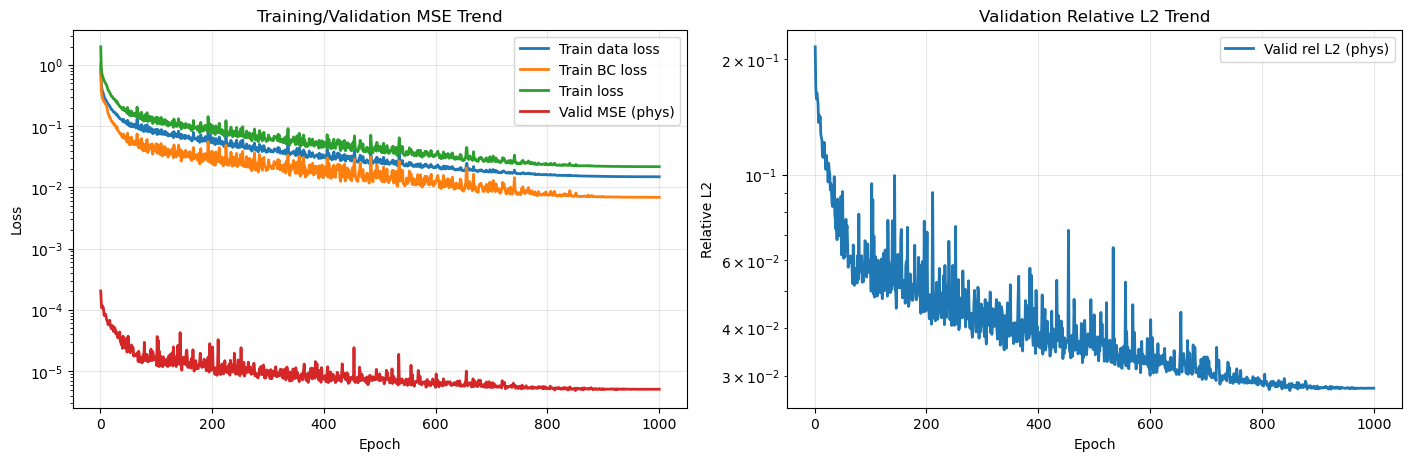

In [12]:
# Plot training/validation loss trend over iterations (epochs).
epochs = np.asarray([h["epoch"] for h in history])
data_loss_arr = np.asarray([h["data_loss"] for h in history])
bc_loss_arr = np.asarray([h["bc_loss"] for h in history])
train_loss_arr = data_loss_arr + bc_loss_arr
valid_loss_arr = np.asarray([h["valid_mse"] for h in history])
valid_rel_l2_arr = np.asarray([h["valid_relative_l2"] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(epochs, data_loss_arr, label="Train data loss", linewidth=2)
axes[0].plot(epochs, bc_loss_arr, label="Train BC loss", linewidth=2)
axes[0].plot(epochs, train_loss_arr, label="Train loss", linewidth=2)
axes[0].plot(epochs, valid_loss_arr, label="Valid MSE (phys)", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training/Validation MSE Trend")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(epochs, valid_rel_l2_arr, label="Valid rel L2 (phys)", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2")
axes[1].set_title("Validation Relative L2 Trend")
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].legend()

plt.show()


## Load best checkpoint

In [13]:
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

best_model = DeepONet(**ckpt["model_config"]).to(DEVICE)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])

print("Loaded:", checkpoint_path)

Loaded: results/060426_1/checkpoint.pt


/tmp/ipykernel_467811/1104796799.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


## Predict validation case

Saved: results/060426_1/predictions/validation/valid_sample_AR10.0_sub0_pressure.png


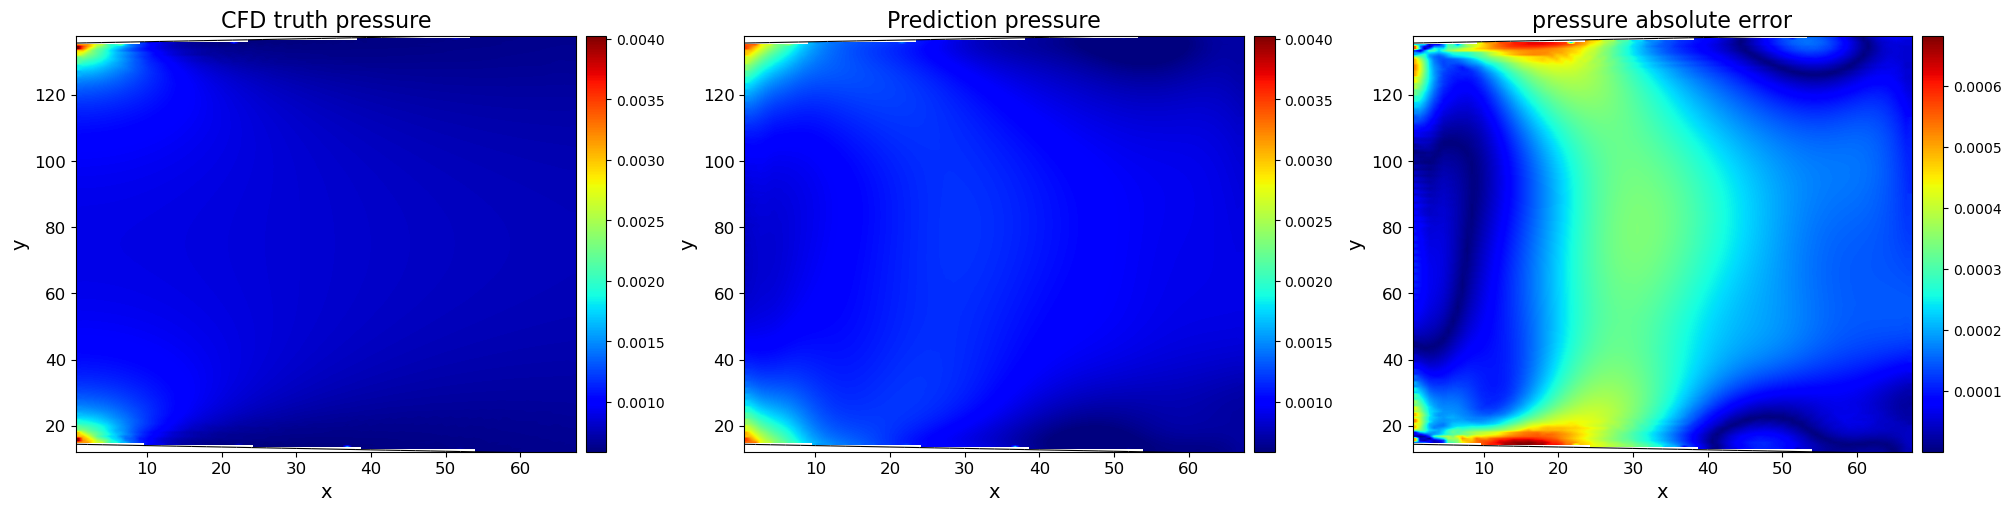

Saved: results/060426_1/predictions/validation/valid_sample_AR10.0_sub0_u.png


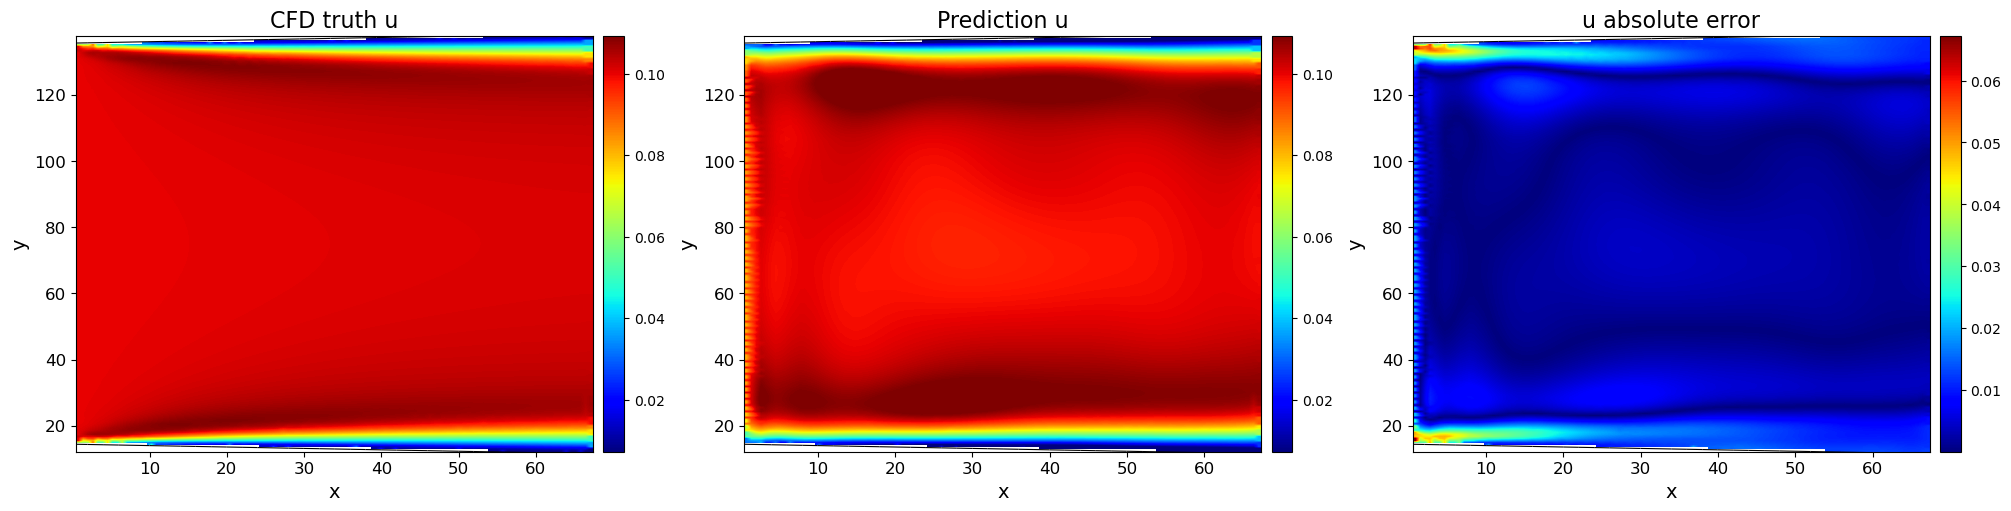

Saved: results/060426_1/predictions/validation/valid_sample_AR10.0_sub0_v.png


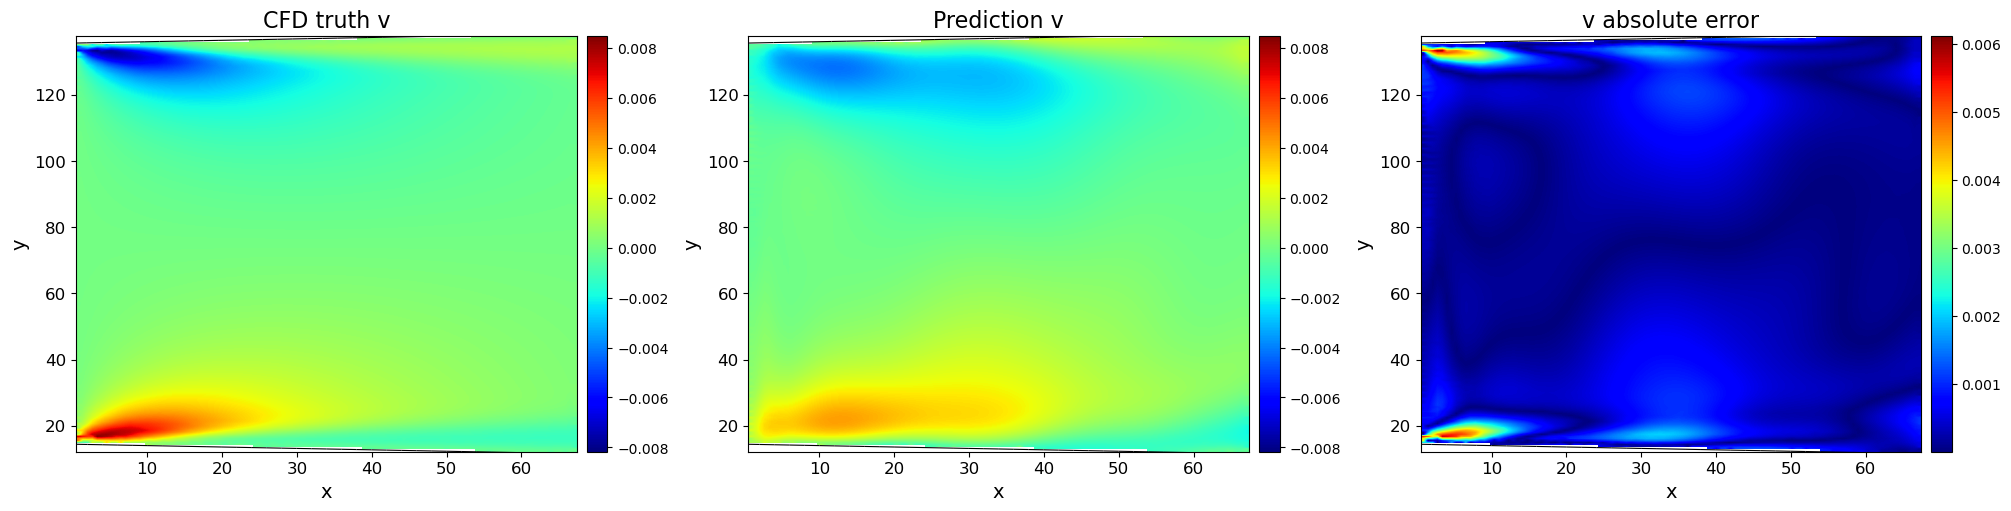

Total plotted points: 130420
x range: 0.5217617 1499.5232
y range: -11.844161 161.80336
Saved: results/060426_1/predictions/validation/valid_case07_AR10_pressure.png


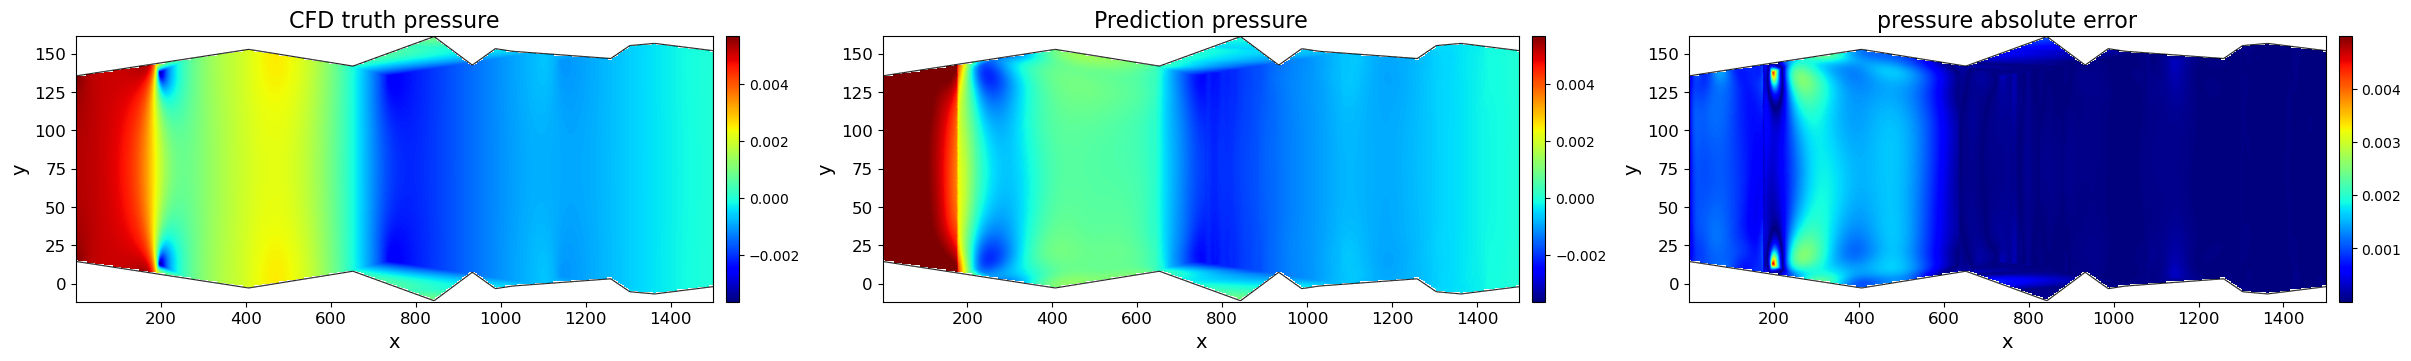

Saved: results/060426_1/predictions/validation/valid_case07_AR10_u.png


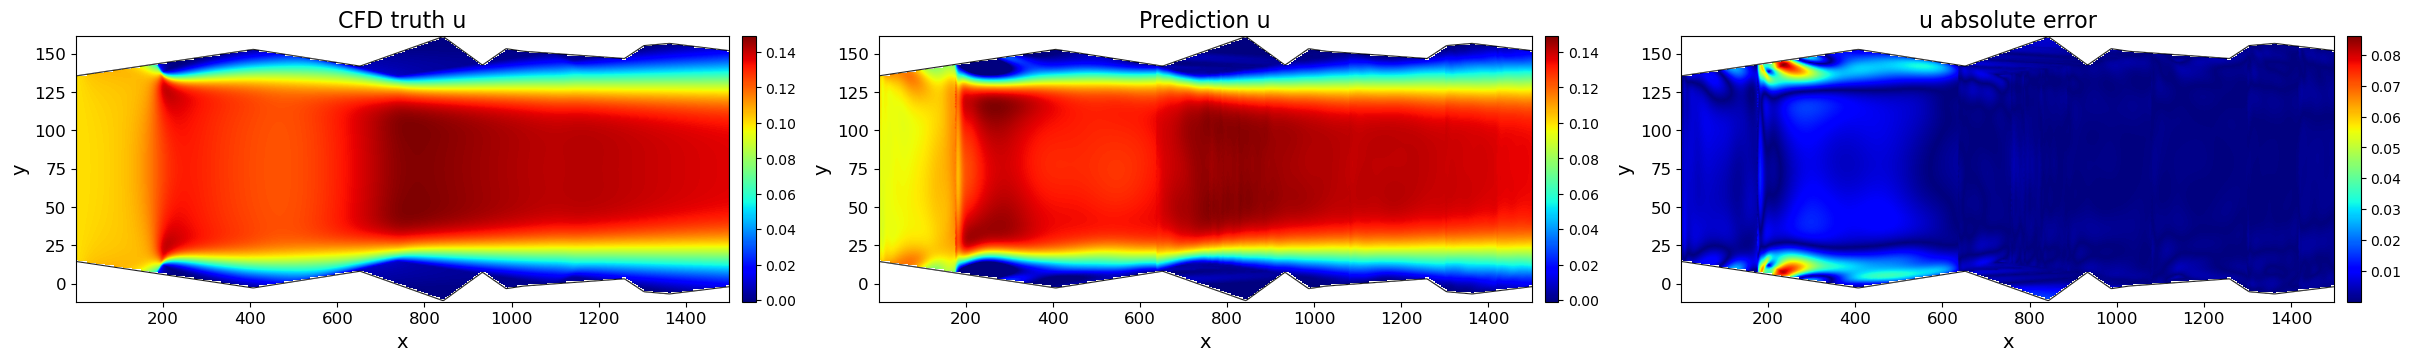

Saved: results/060426_1/predictions/validation/valid_case07_AR10_v.png


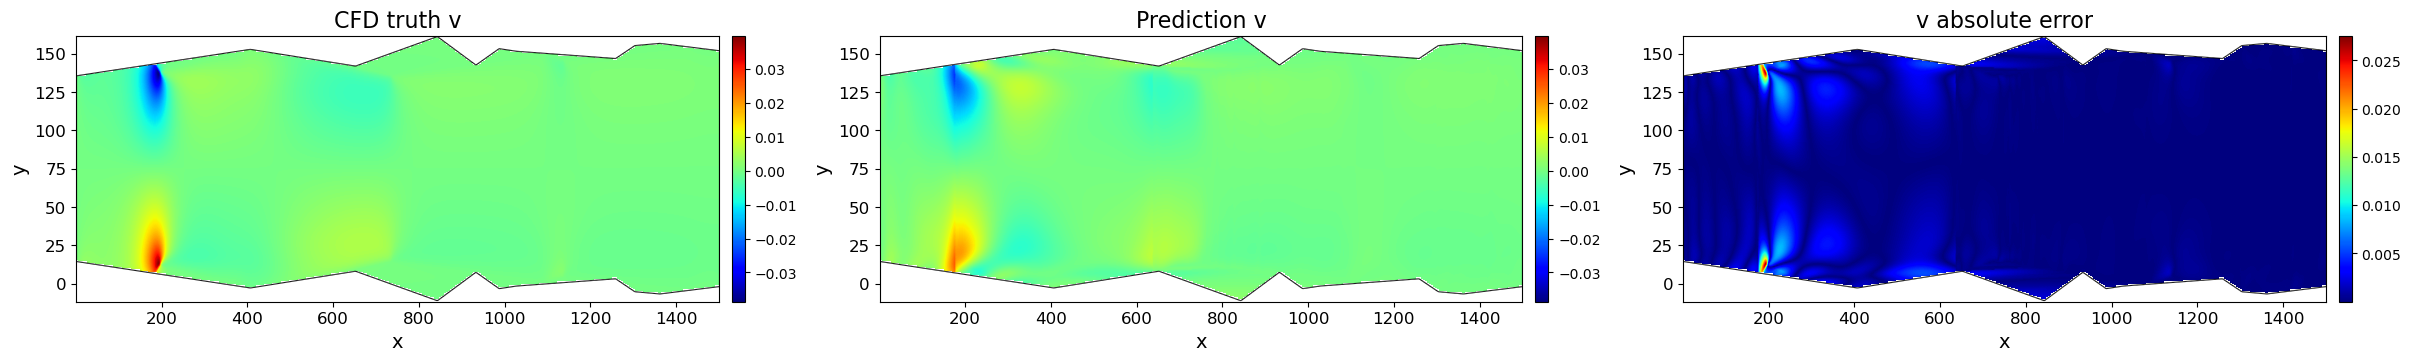

In [19]:
valid_sample_id = 20

sample = valid_data["samples"][valid_sample_id]
metadata = valid_data["metadata"][valid_sample_id]
output_channel_names = list(valid_data["output_channel_names"])

pred_phys = predict_cell_sample(
    model=model,
    sample=sample,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

query_local = np.asarray(sample["query"], dtype=np.float32)
truth_phys = np.asarray(sample["target"], dtype=np.float32)

x_phys, y_phys = local_query_to_physical(query_local, metadata)

for field_idx, field_name in enumerate(output_channel_names):
    plot_prediction_imshow_from_points(
        x=x_phys,
        y=y_phys,
        pred=pred_phys,
        truth=truth_phys,
        field_name=field_name,
        field_idx=field_idx,
        figsize=(20, 5),
        n_y_plot=200,
        mesh_h5=case_files[metadata["case_id"]]["mesh"],
        output_dir=output_dir / "predictions" / "validation",
        filename_prefix=f"valid_sample_AR{metadata['aspect_ratio']}_sub{metadata['subdomain_id']}",
    )
    
PLOT_VALID_CASE = VALID_CASES[0]

valid_case_sample_ids = sorted(
    (i for i, mm in enumerate(valid_data["metadata"]) if int(mm["case_id"]) == int(PLOT_VALID_CASE)),
    key=lambda i: int(valid_data["metadata"][i]["subdomain_id"]),
)
AR_TO_PLOT = int(round(valid_data["metadata"][valid_case_sample_ids[0]]["aspect_ratio"]))

plot_data = collect_predictions_for_data(
    model=model,
    data=valid_data,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    sample_indices=valid_case_sample_ids,
)

print("Total plotted points:", plot_data["x"].shape[0])
print("x range:", plot_data["x"].min(), plot_data["x"].max())
print("y range:", plot_data["y"].min(), plot_data["y"].max())

for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=plot_data["x"],
        y=plot_data["y"],
        pred=plot_data["pred"],
        truth=plot_data["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_x_plot=200 * AR_TO_PLOT,
        n_y_plot=200,
        mesh_h5=case_files[metadata["case_id"]]["mesh"],
        output_dir=output_dir / "predictions" / "validation",
        filename_prefix=f"valid_case{PLOT_VALID_CASE:02d}_AR{AR_TO_PLOT}",
    )

# Predict test case

In [ ]:
test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=TEST_CASES,
    n_subdomains=N_SUBDOMAINS,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement="fixed",
    interface_jitter=0,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)
print("Test samples:", len(test_data["samples"]))
print("Test cases:", sorted({int(m["case_id"]) for m in test_data["metadata"]}))

Total plotted points: 129802
x range: 0.5177064 1499.4655
y range: -12.175907 162.1532
Saved: results/060426_1/predictions/test/test_case29_pressure.png


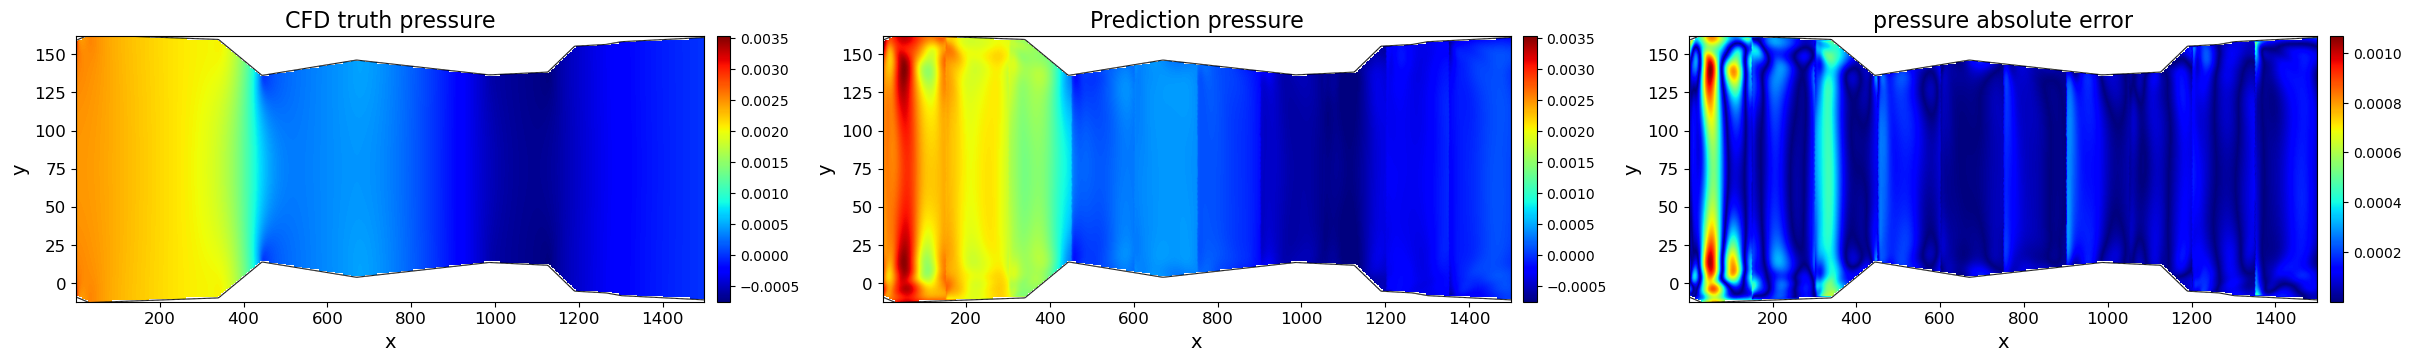

Saved: results/060426_1/predictions/test/test_case29_u.png


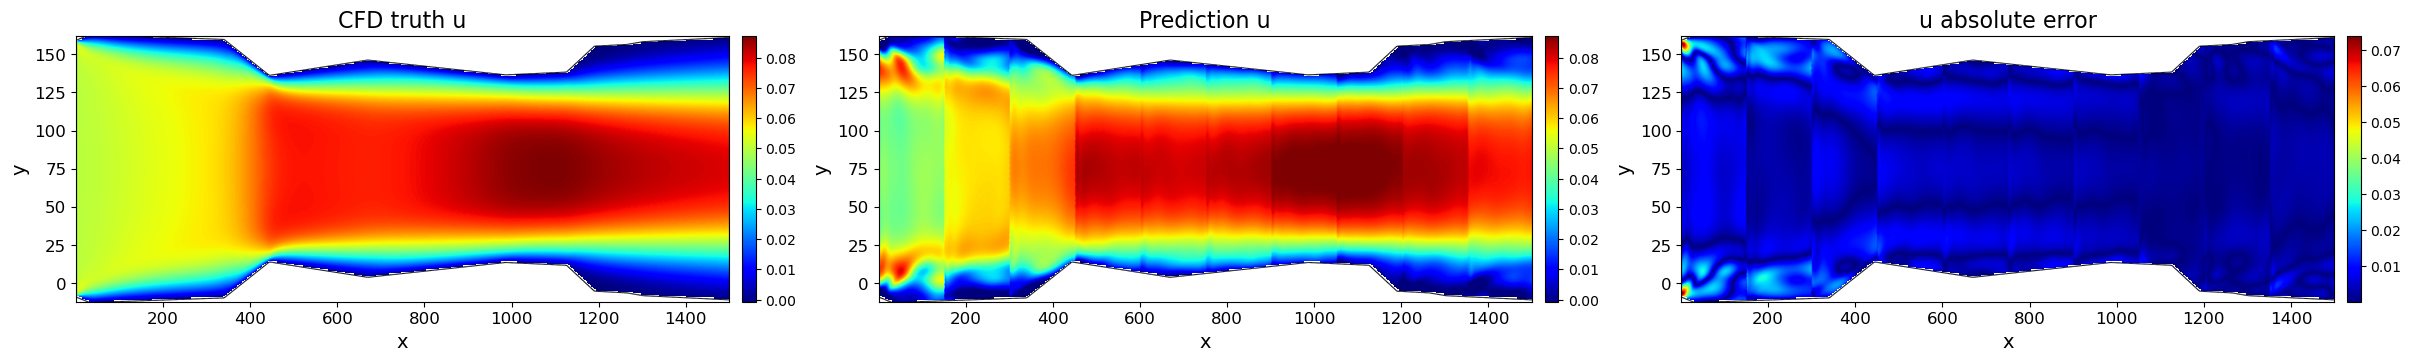

Saved: results/060426_1/predictions/test/test_case29_v.png


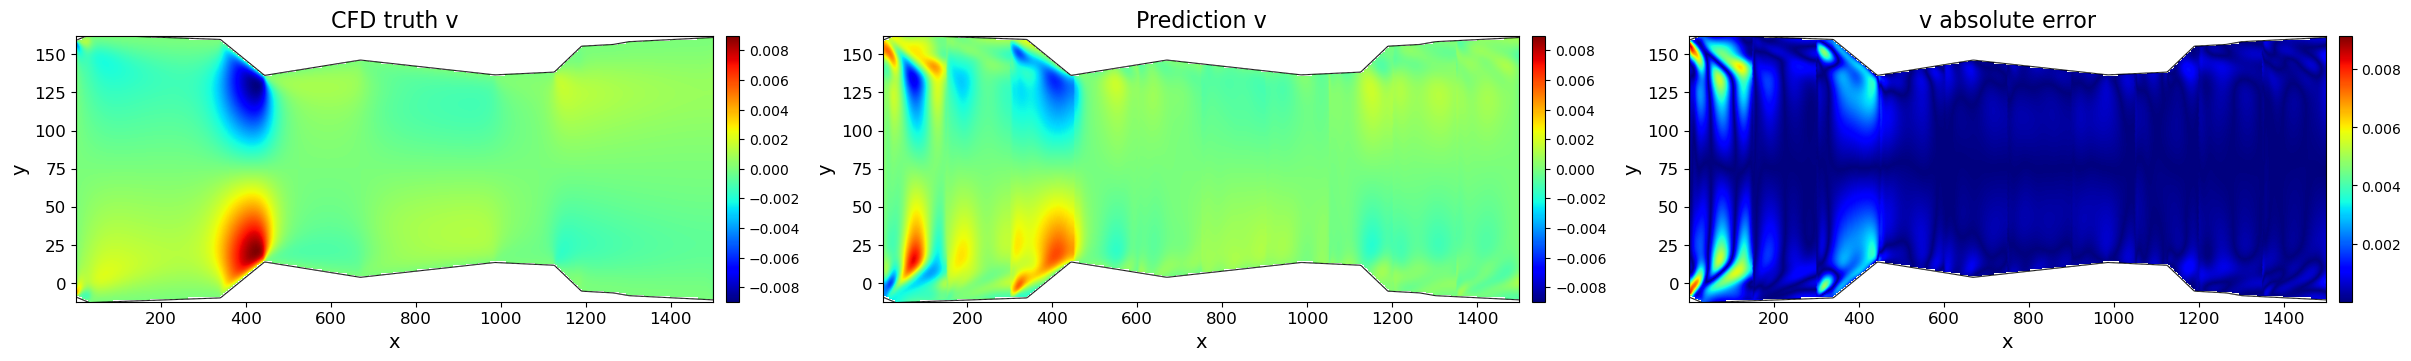

Total plotted points: 122754
x range: 0.51921827 1499.4724
y range: -13.061268 163.10059
Saved: results/060426_1/predictions/test/test_case33_pressure.png


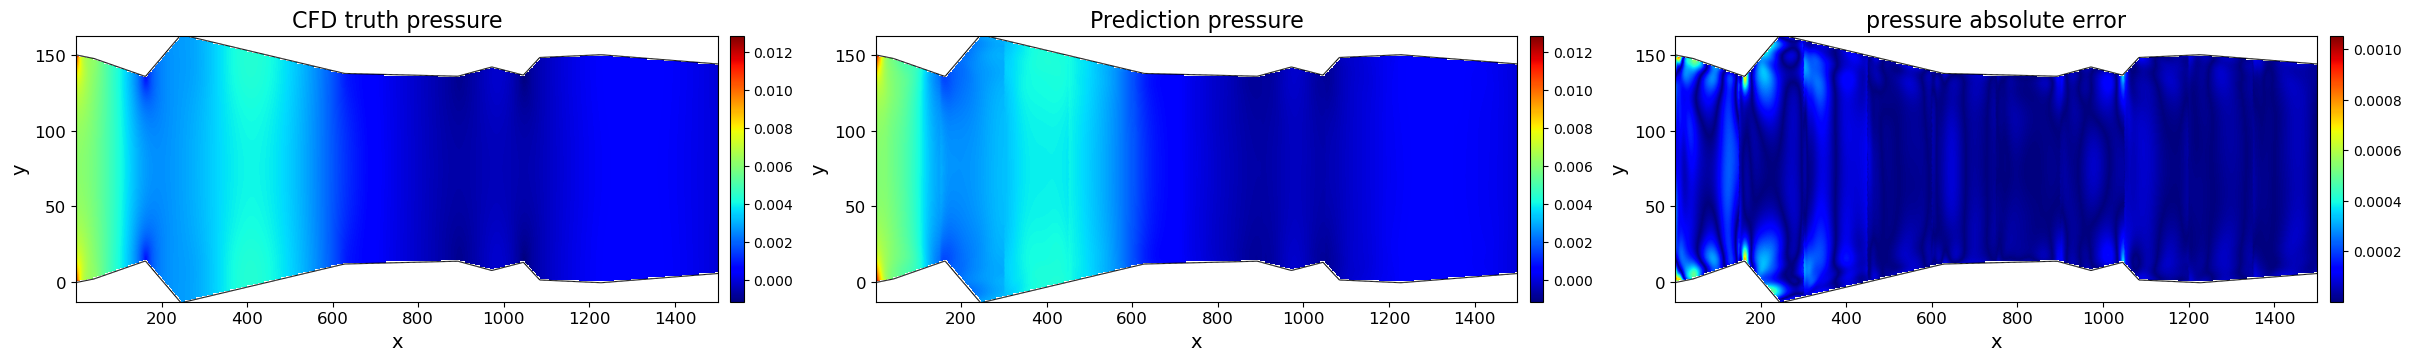

Saved: results/060426_1/predictions/test/test_case33_u.png


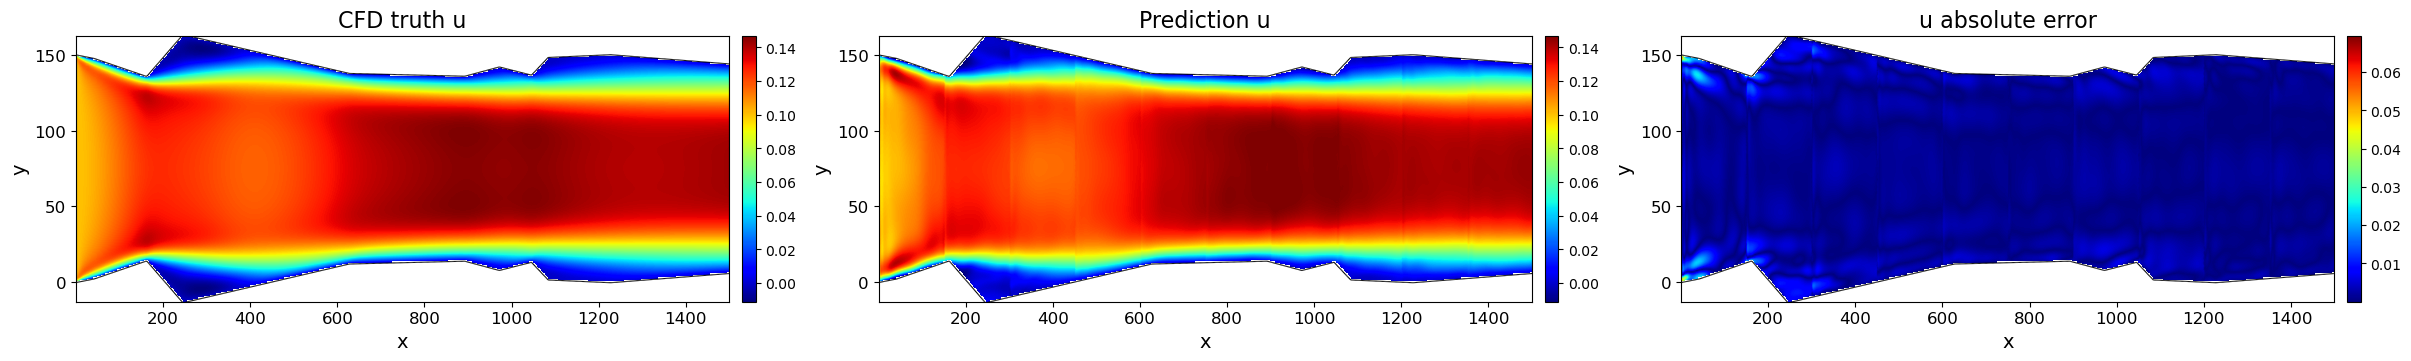

Saved: results/060426_1/predictions/test/test_case33_v.png


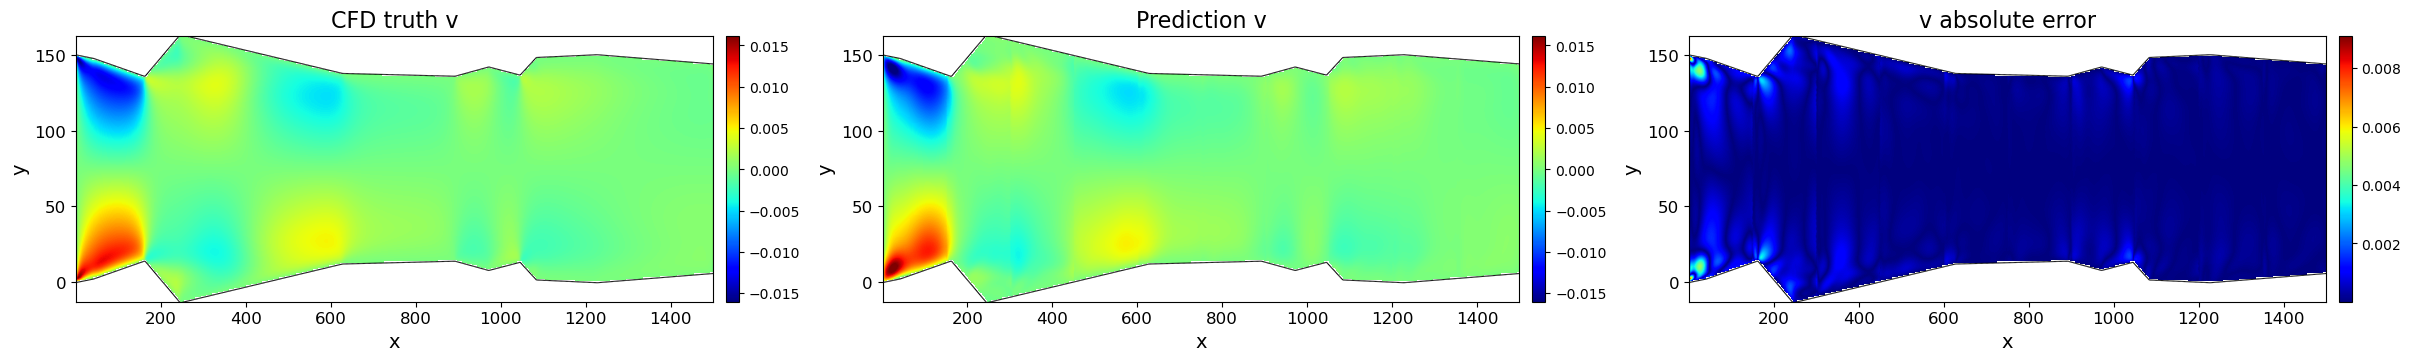

Total plotted points: 124219
x range: 0.5323179 1499.5037
y range: -12.926371 162.89456
Saved: results/060426_1/predictions/test/test_case41_pressure.png


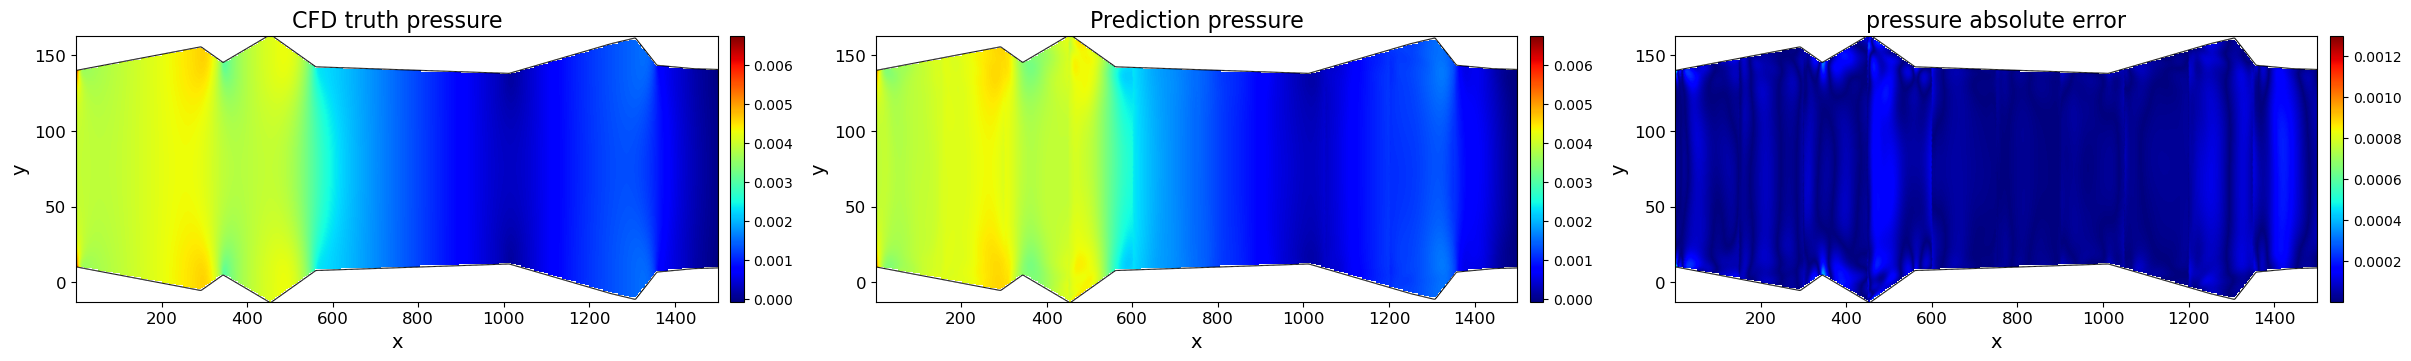

Saved: results/060426_1/predictions/test/test_case41_u.png


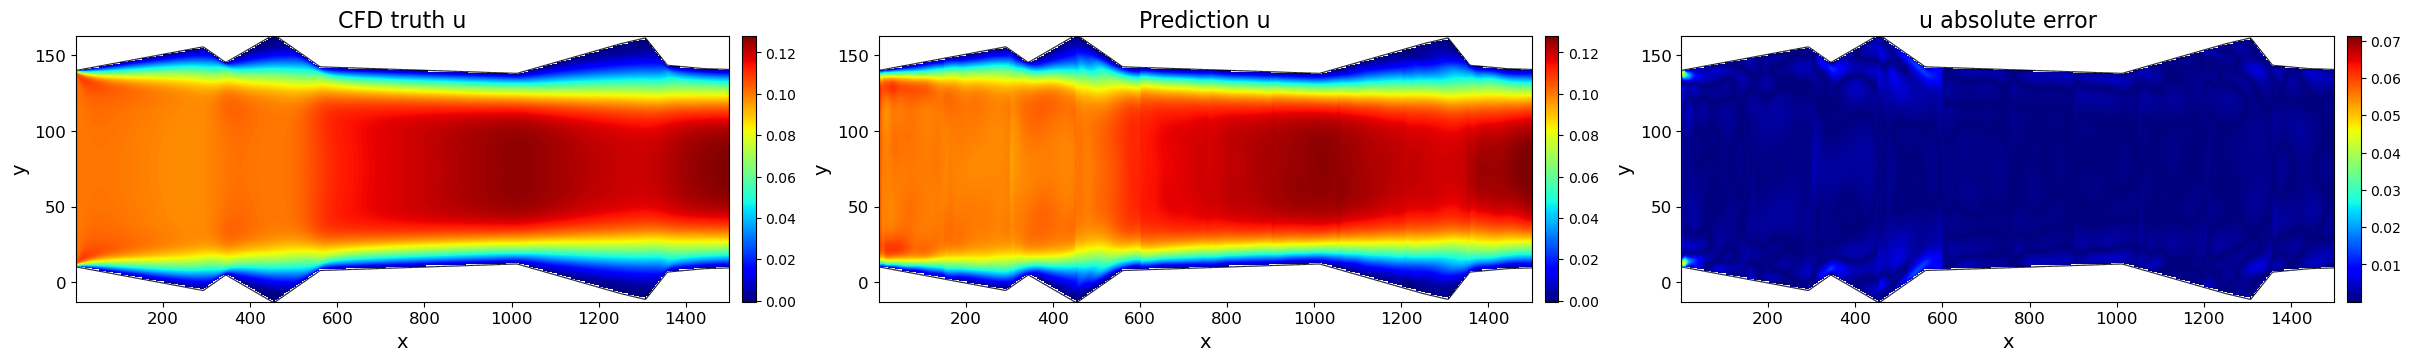

Saved: results/060426_1/predictions/test/test_case41_v.png


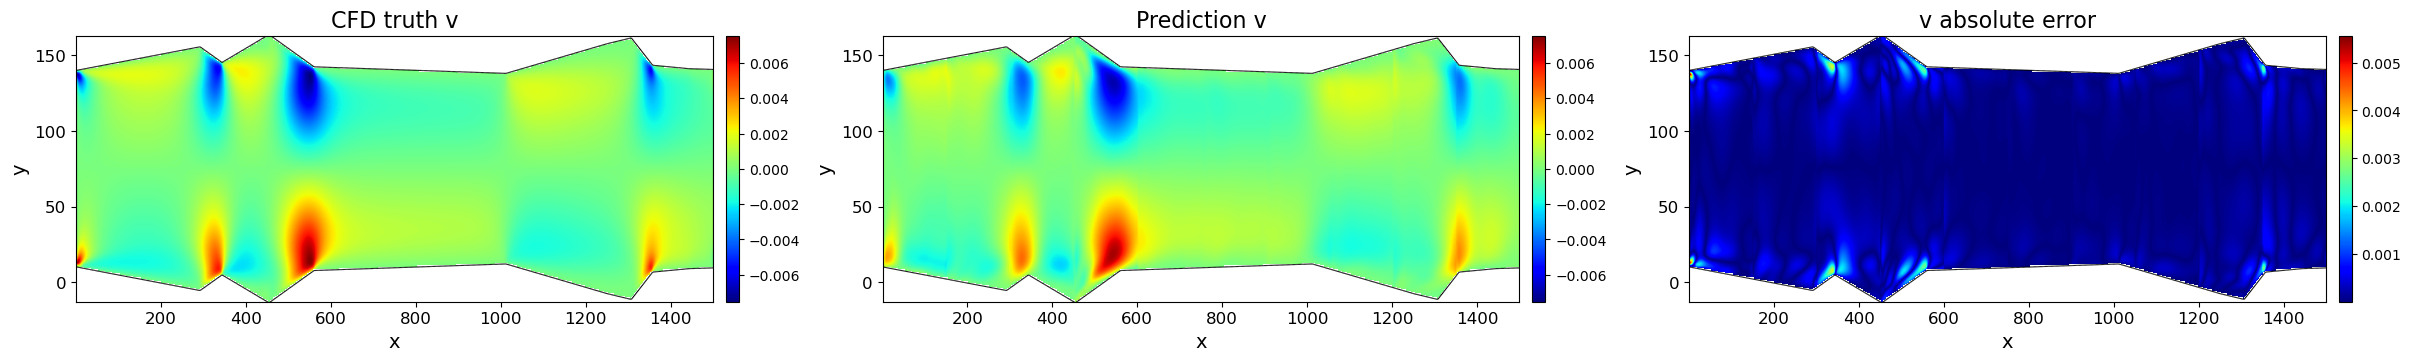

Total plotted points: 128771
x range: 0.516621 1499.5321
y range: -10.2581415 160.23286
Saved: results/060426_1/predictions/test/test_case54_pressure.png


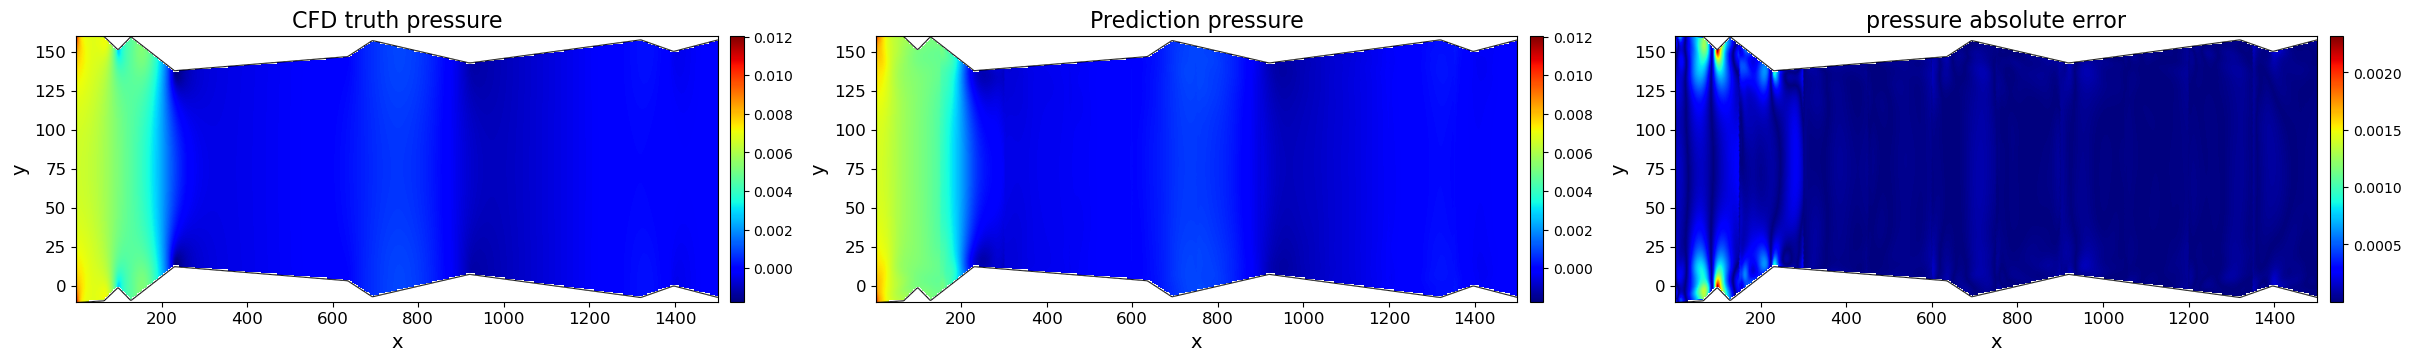

Saved: results/060426_1/predictions/test/test_case54_u.png


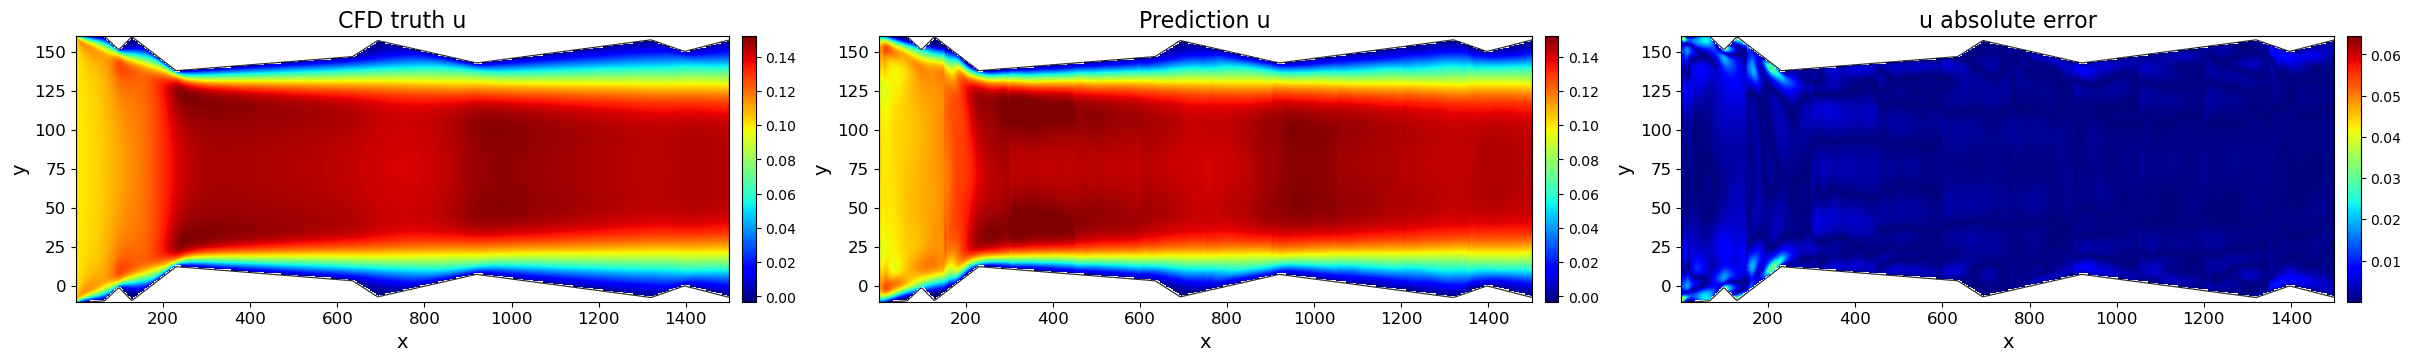

Saved: results/060426_1/predictions/test/test_case54_v.png


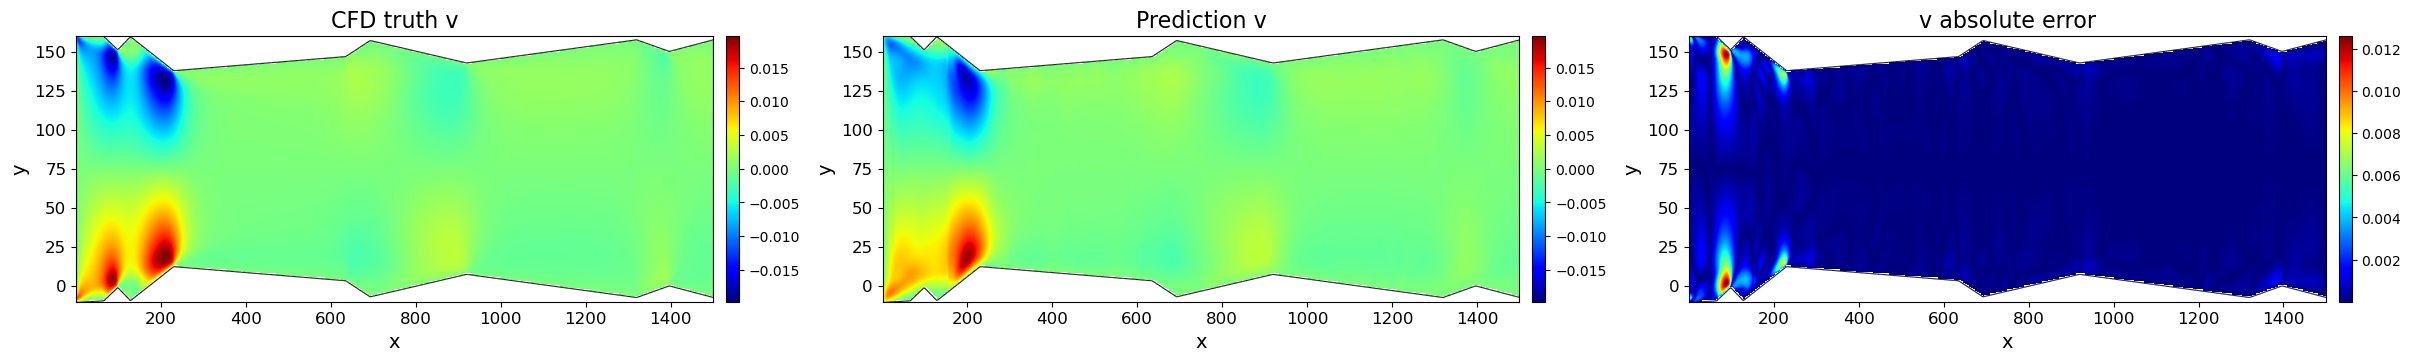

Total plotted points: 128646
x range: 0.52389157 1499.4886
y range: -9.192306 159.20416
Saved: results/060426_1/predictions/test/test_case56_pressure.png


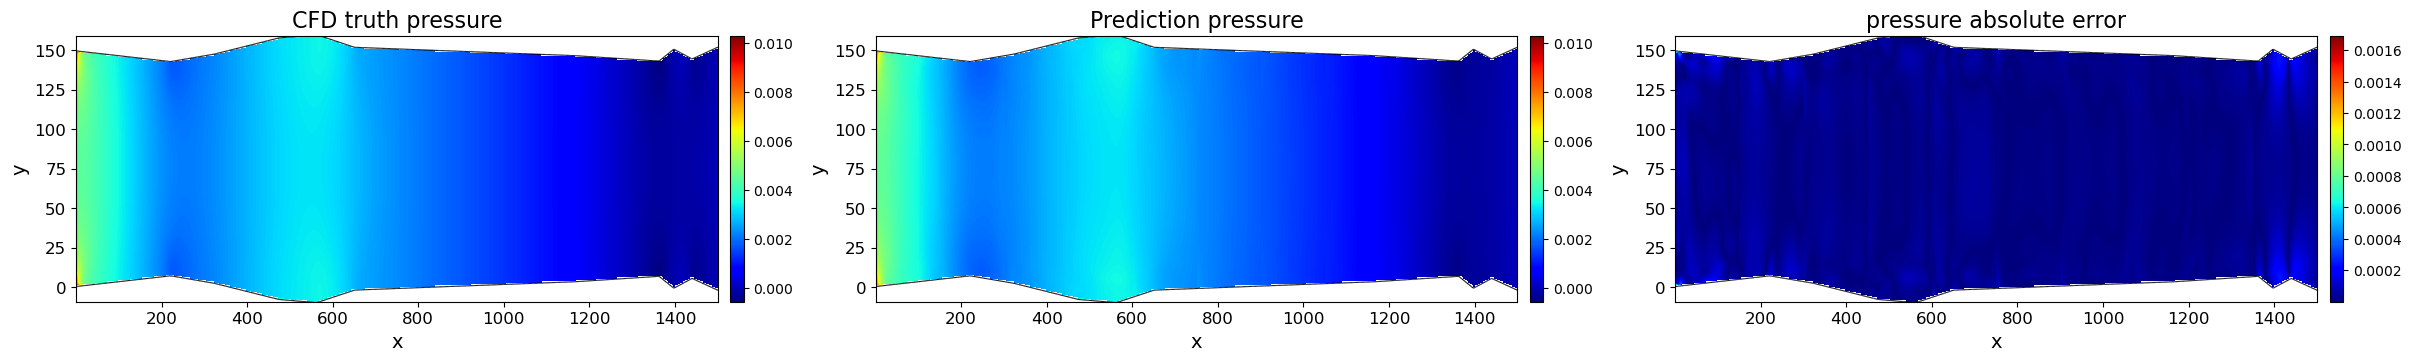

Saved: results/060426_1/predictions/test/test_case56_u.png


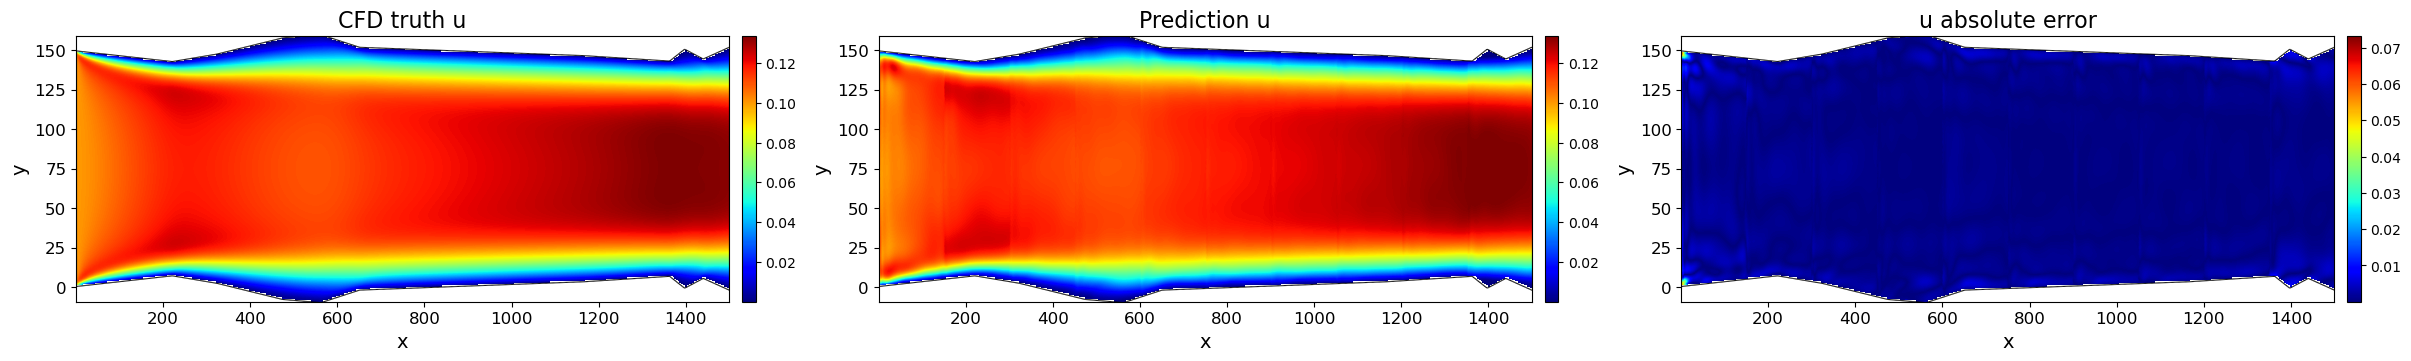

Saved: results/060426_1/predictions/test/test_case56_v.png


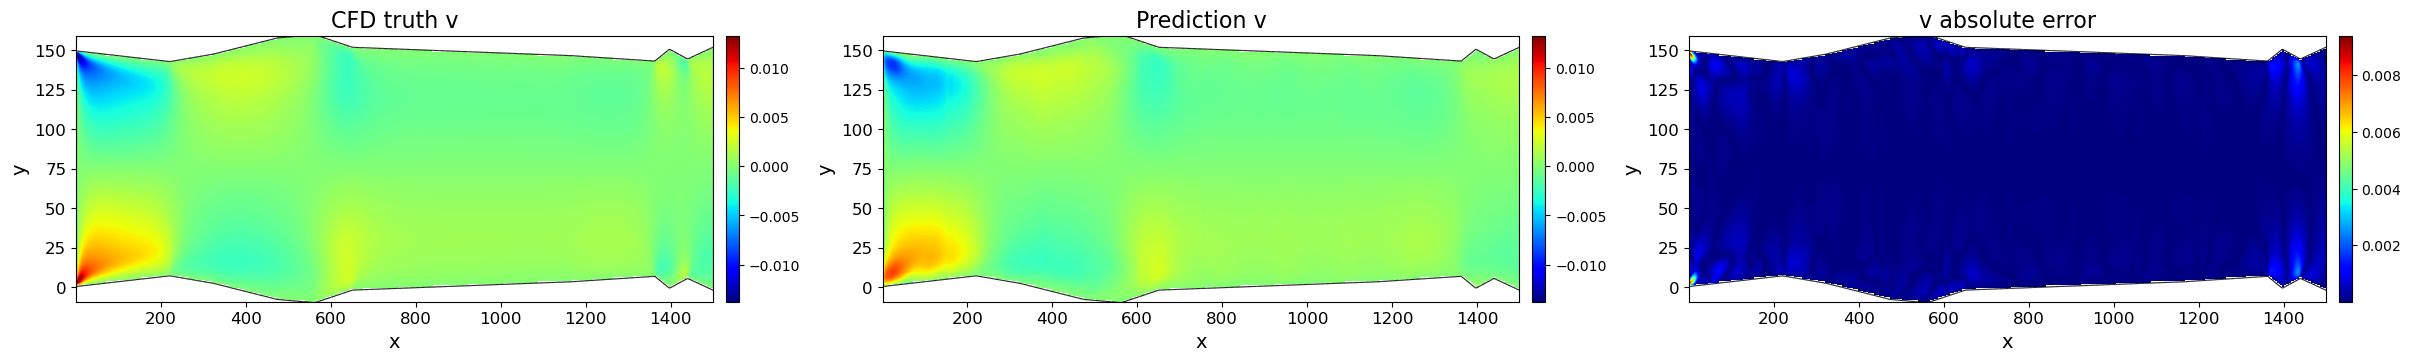

Total plotted points: 125694
x range: 0.49380285 1499.5012
y range: -13.248488 163.26027
Saved: results/060426_1/predictions/test/test_case59_pressure.png


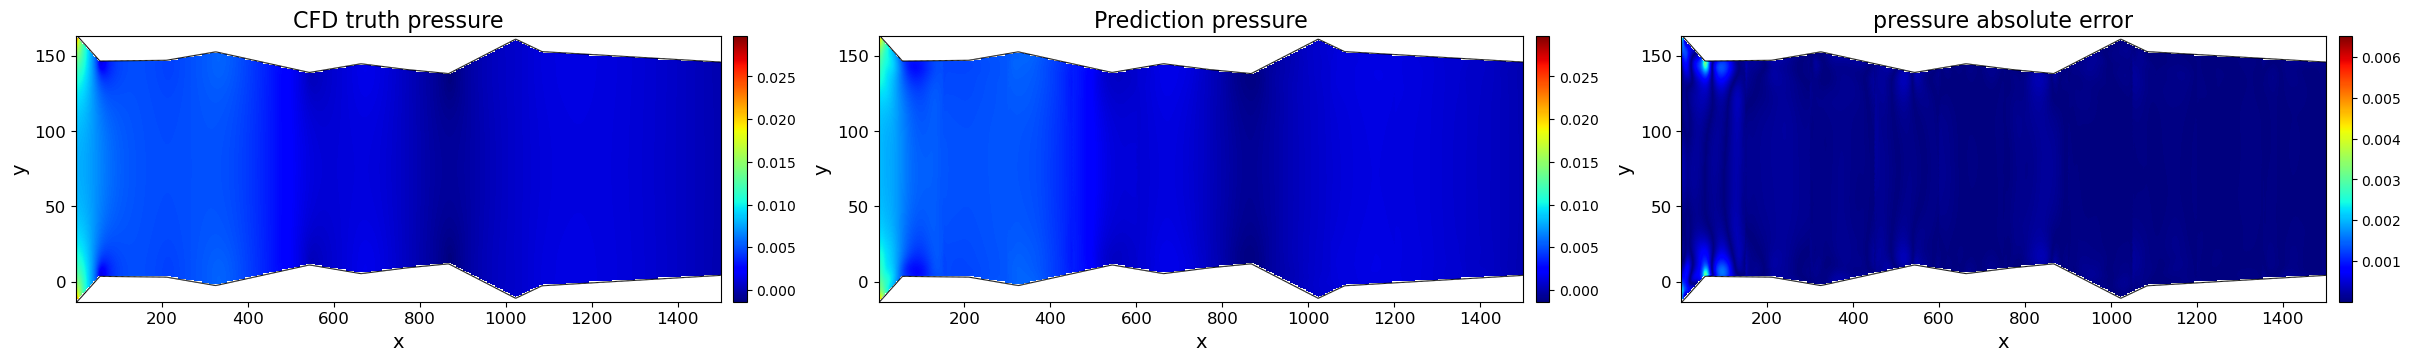

Saved: results/060426_1/predictions/test/test_case59_u.png


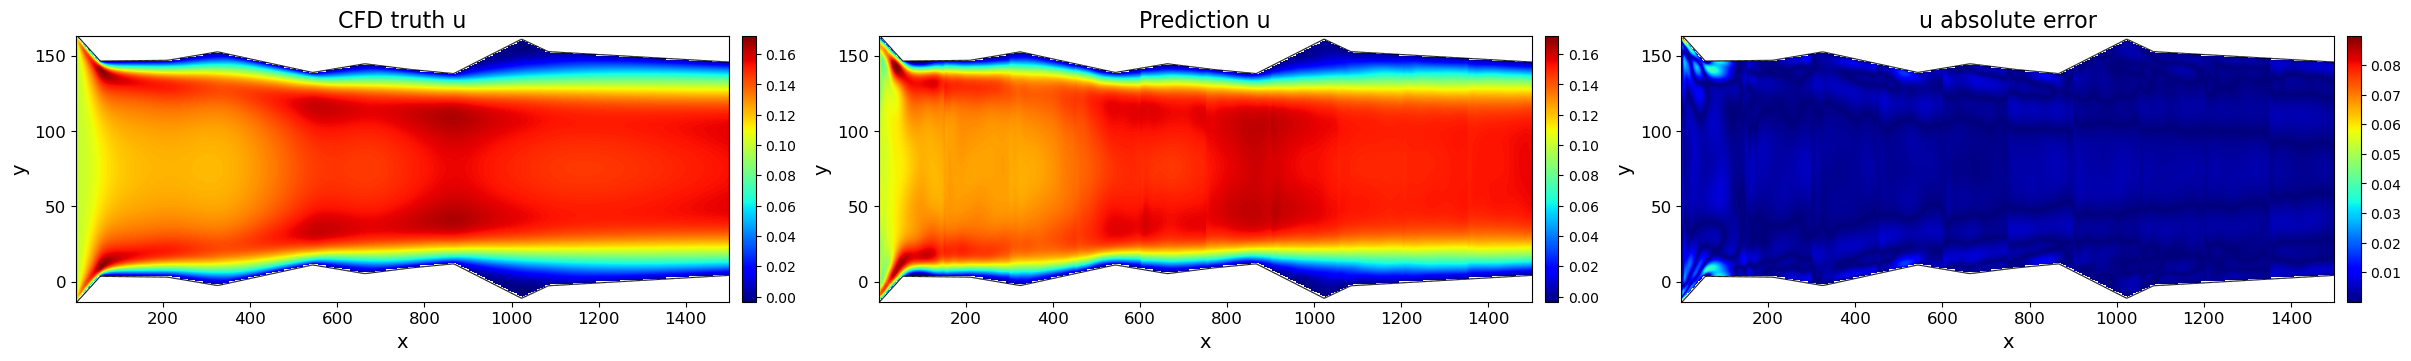

Saved: results/060426_1/predictions/test/test_case59_v.png


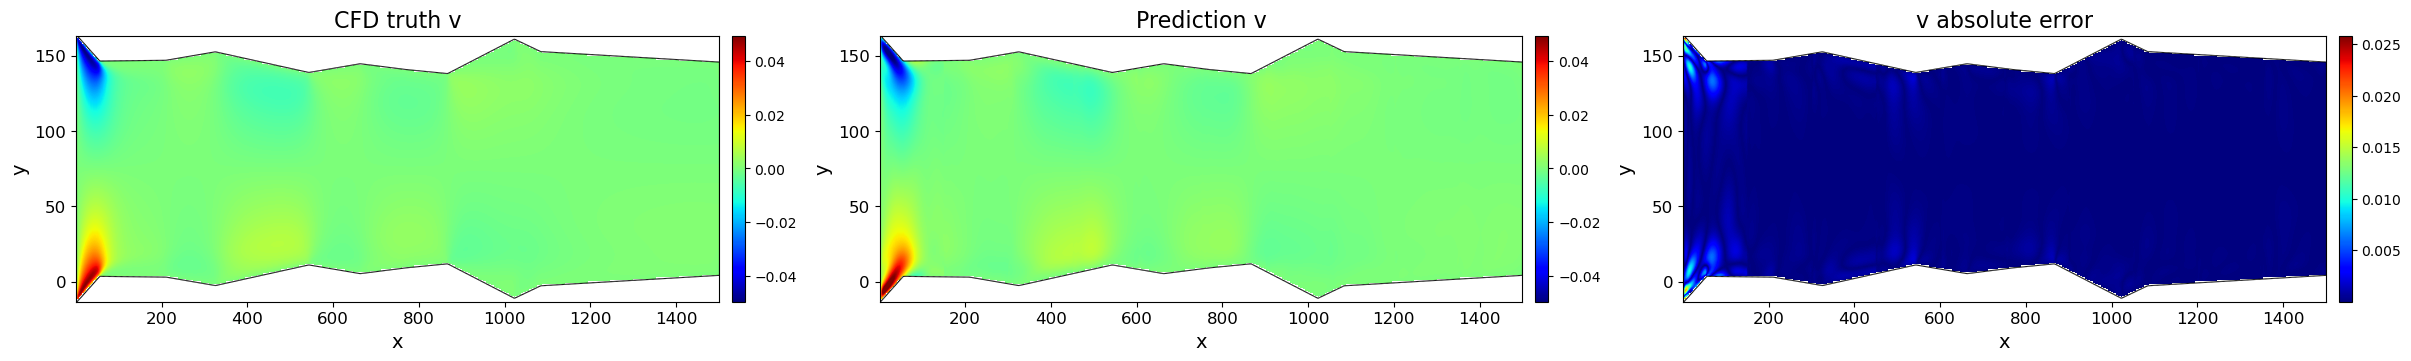

Total plotted points: 134066
x range: 0.4880383 1499.4592
y range: -13.662997 163.74352
Saved: results/060426_1/predictions/test/test_case69_pressure.png


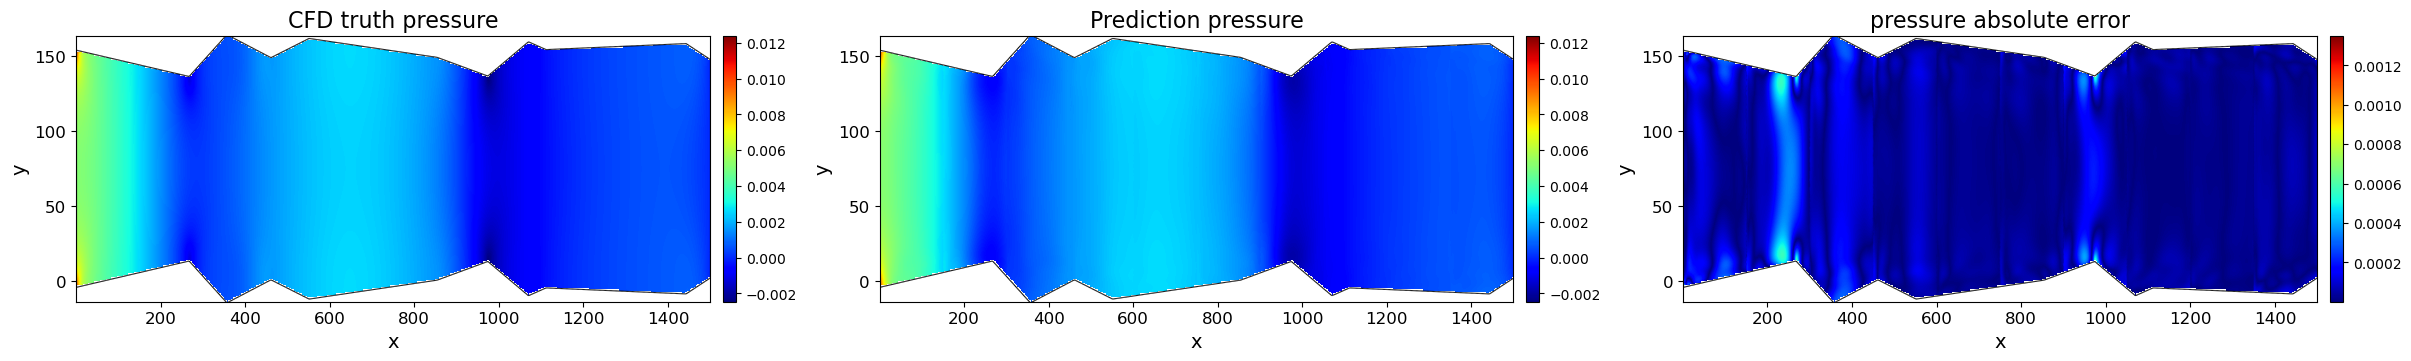

Saved: results/060426_1/predictions/test/test_case69_u.png


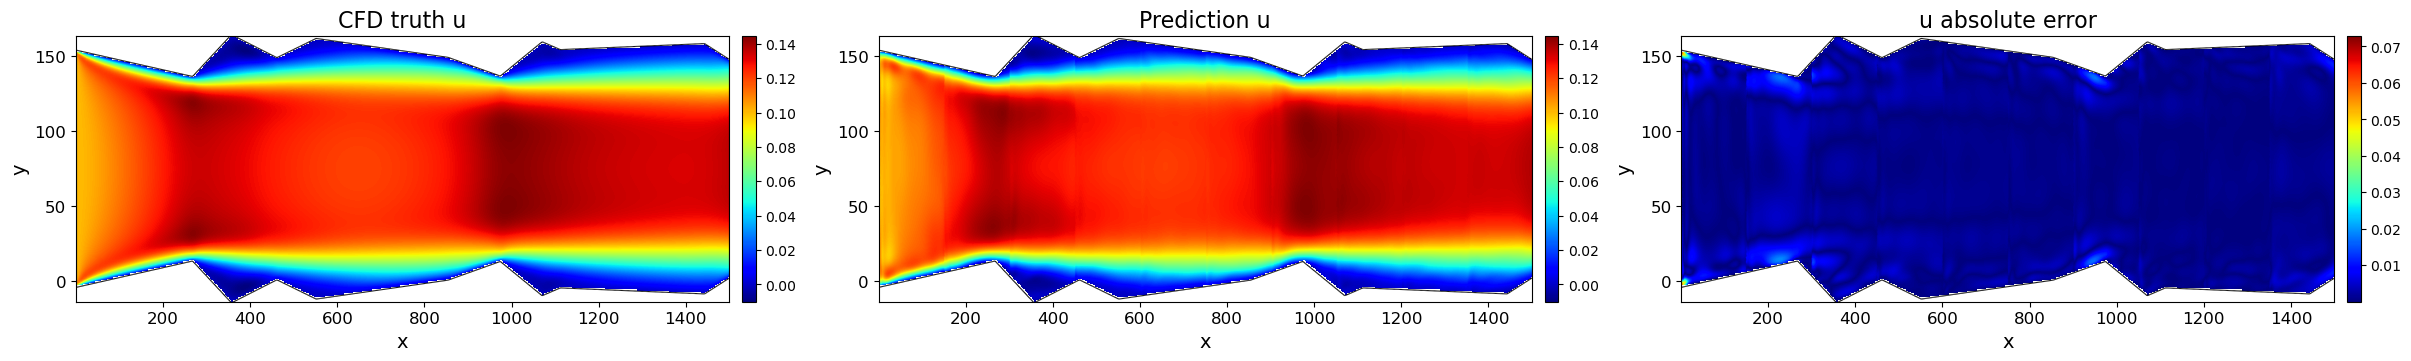

Saved: results/060426_1/predictions/test/test_case69_v.png


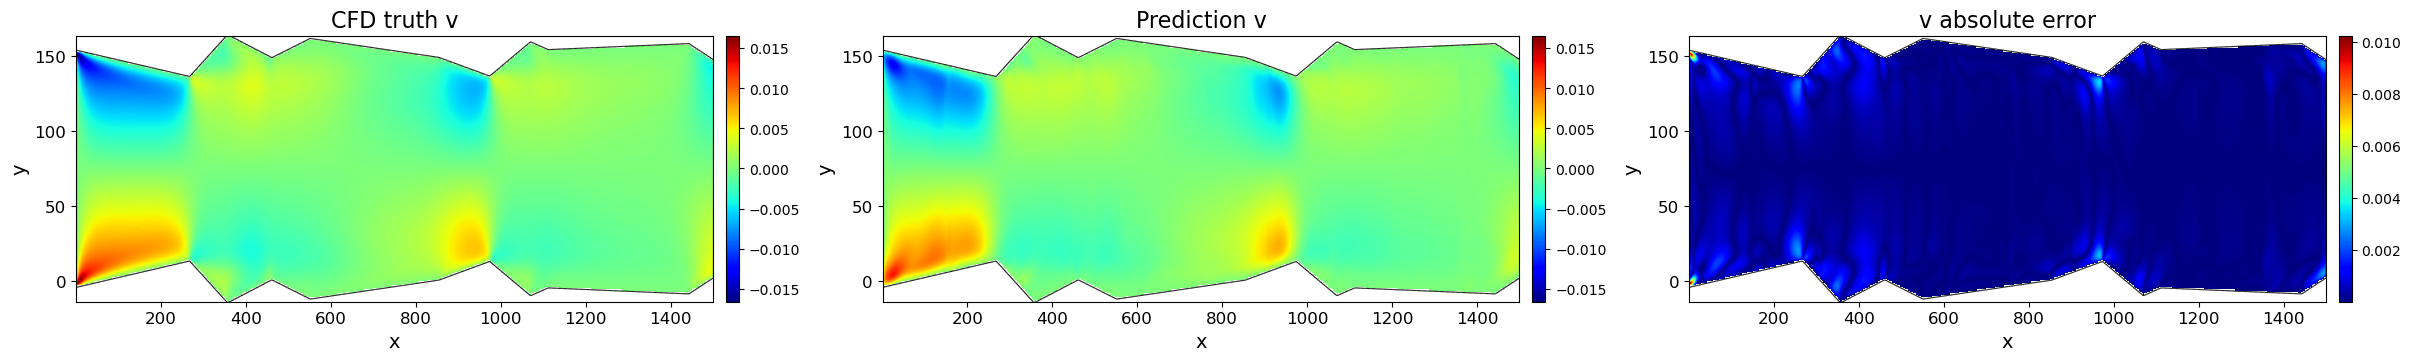

Total plotted points: 136499
x range: 0.5037642 1499.4736
y range: -12.572839 162.55254
Saved: results/060426_1/predictions/test/test_case78_pressure.png


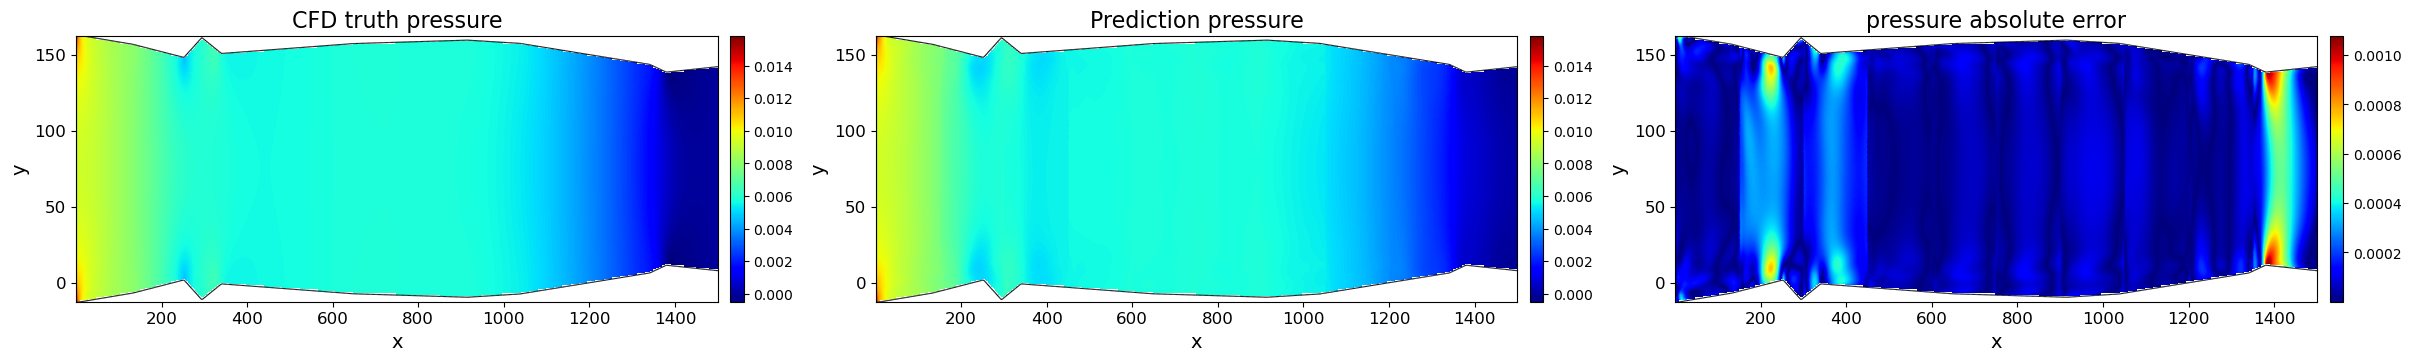

Saved: results/060426_1/predictions/test/test_case78_u.png


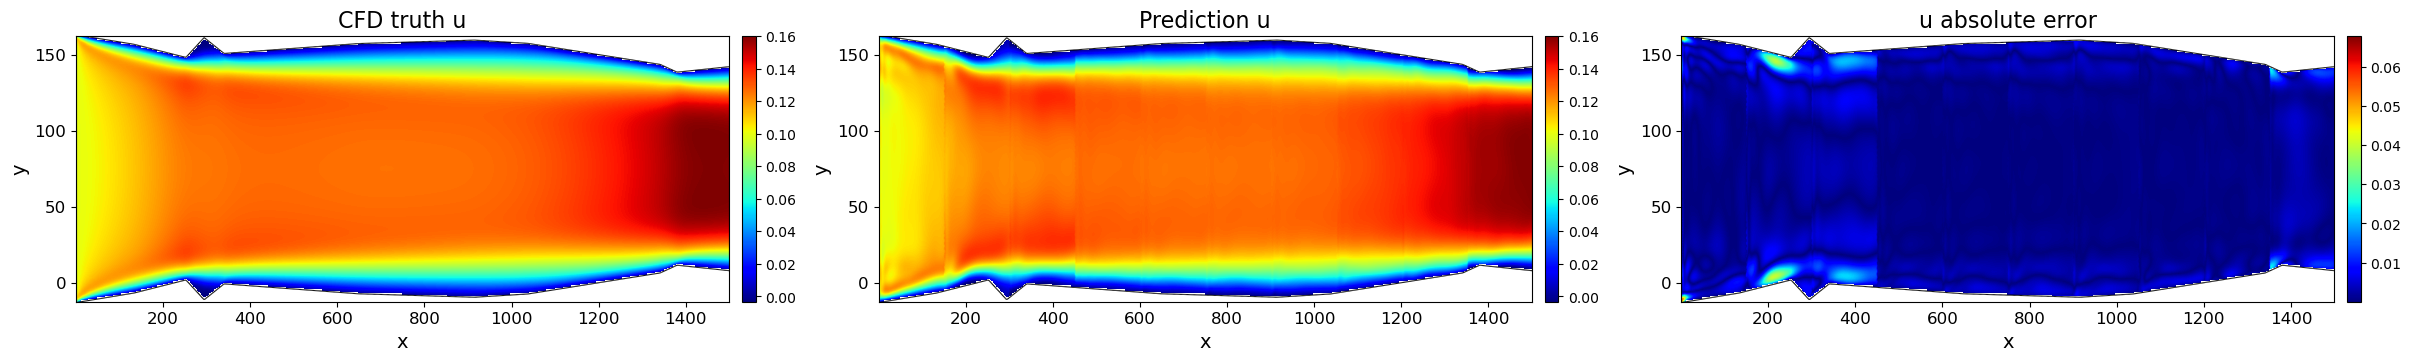

Saved: results/060426_1/predictions/test/test_case78_v.png


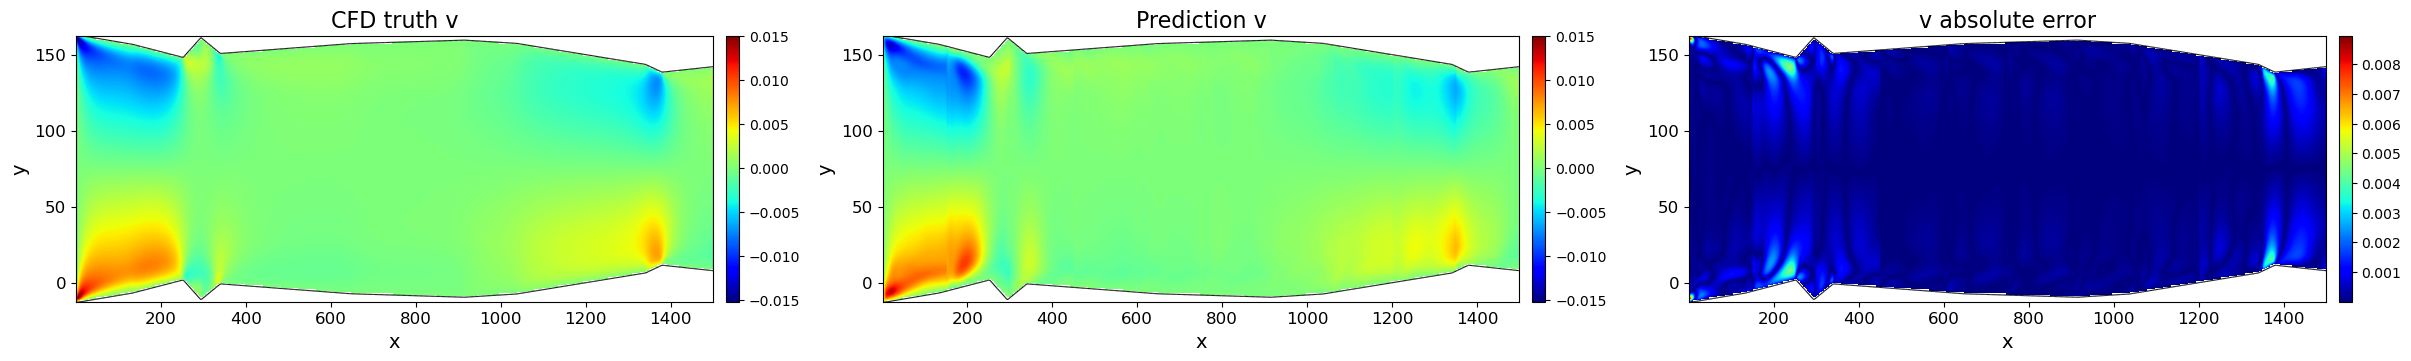

Total plotted points: 145341
x range: 0.5376634 1499.4445
y range: -13.943932 163.95926
Saved: results/060426_1/predictions/test/test_case79_pressure.png


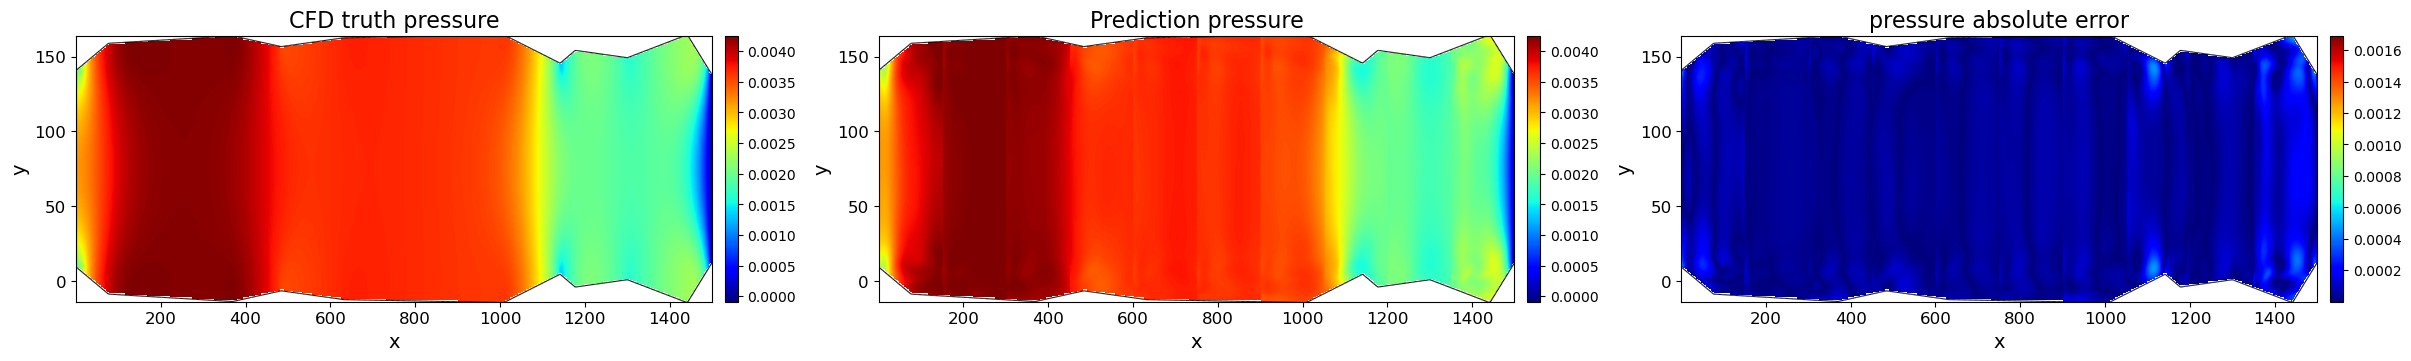

Saved: results/060426_1/predictions/test/test_case79_u.png


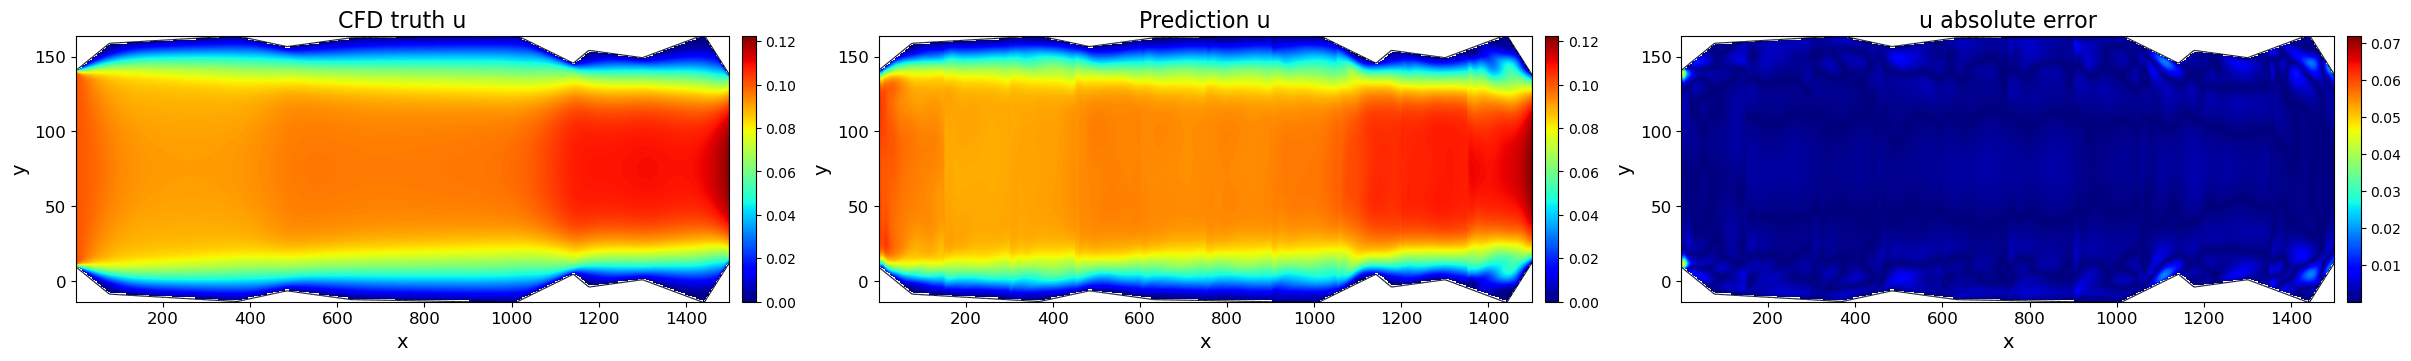

Saved: results/060426_1/predictions/test/test_case79_v.png


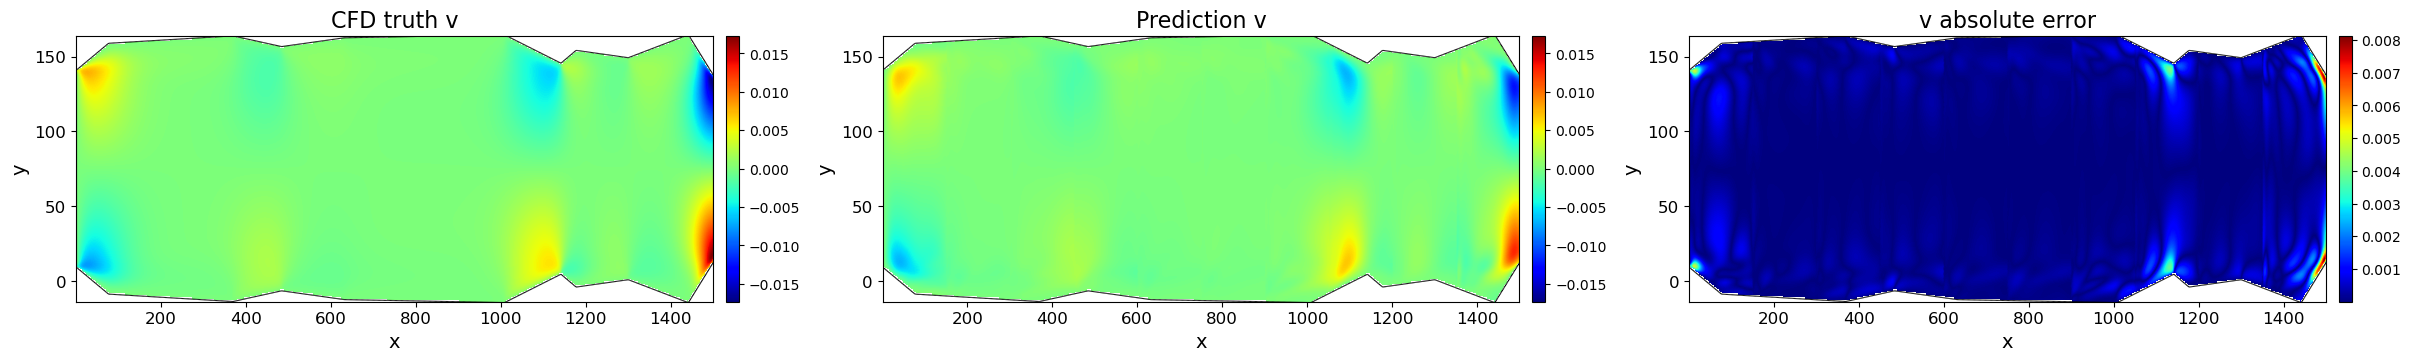

Total plotted points: 137598
x range: 0.47674653 1499.5122
y range: -13.857688 163.80327
Saved: results/060426_1/predictions/test/test_case95_pressure.png


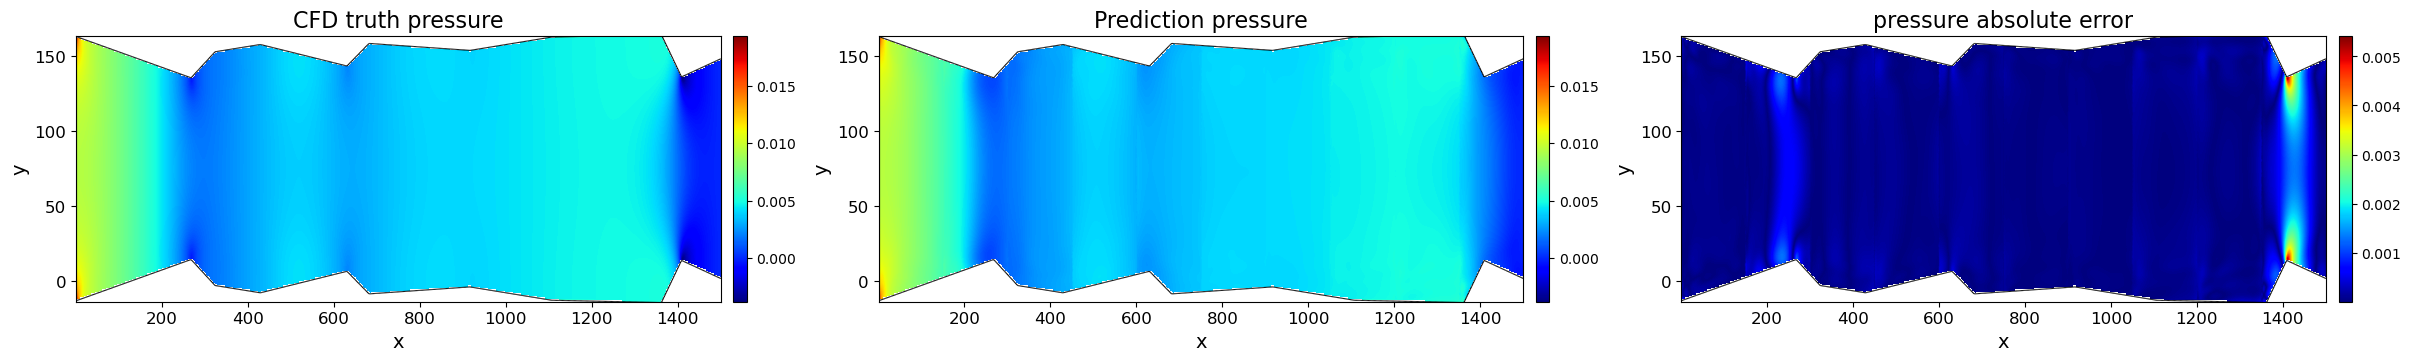

Saved: results/060426_1/predictions/test/test_case95_u.png


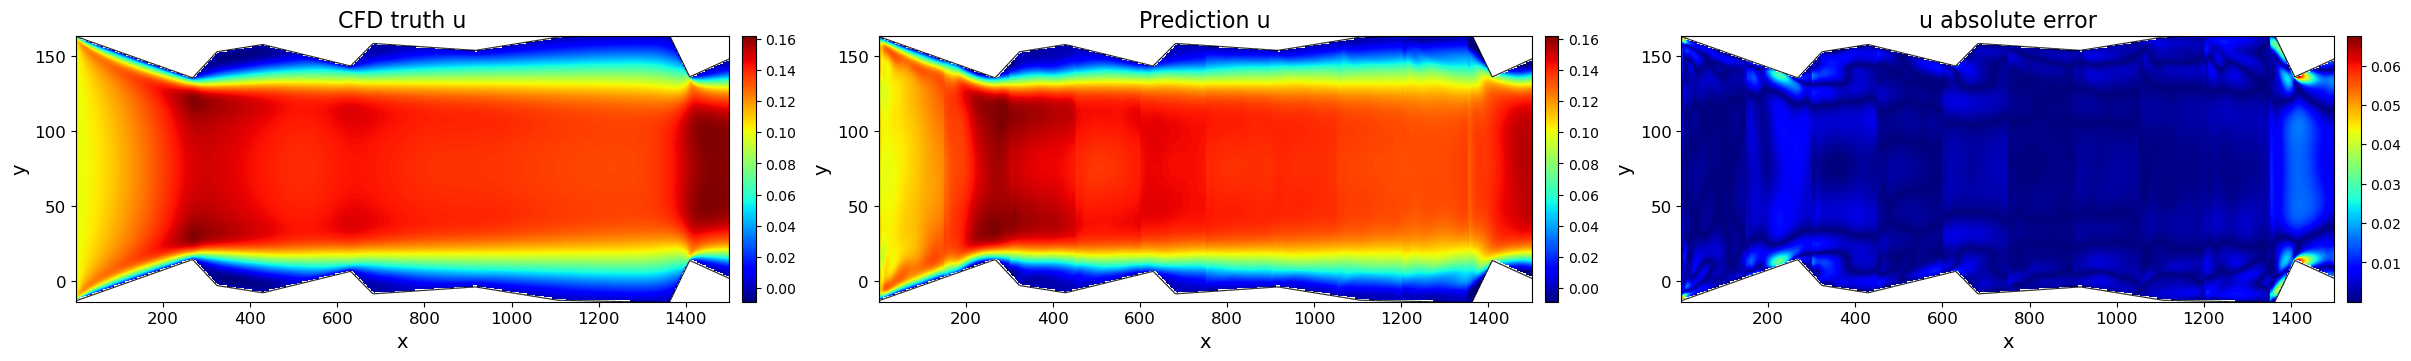

Saved: results/060426_1/predictions/test/test_case95_v.png


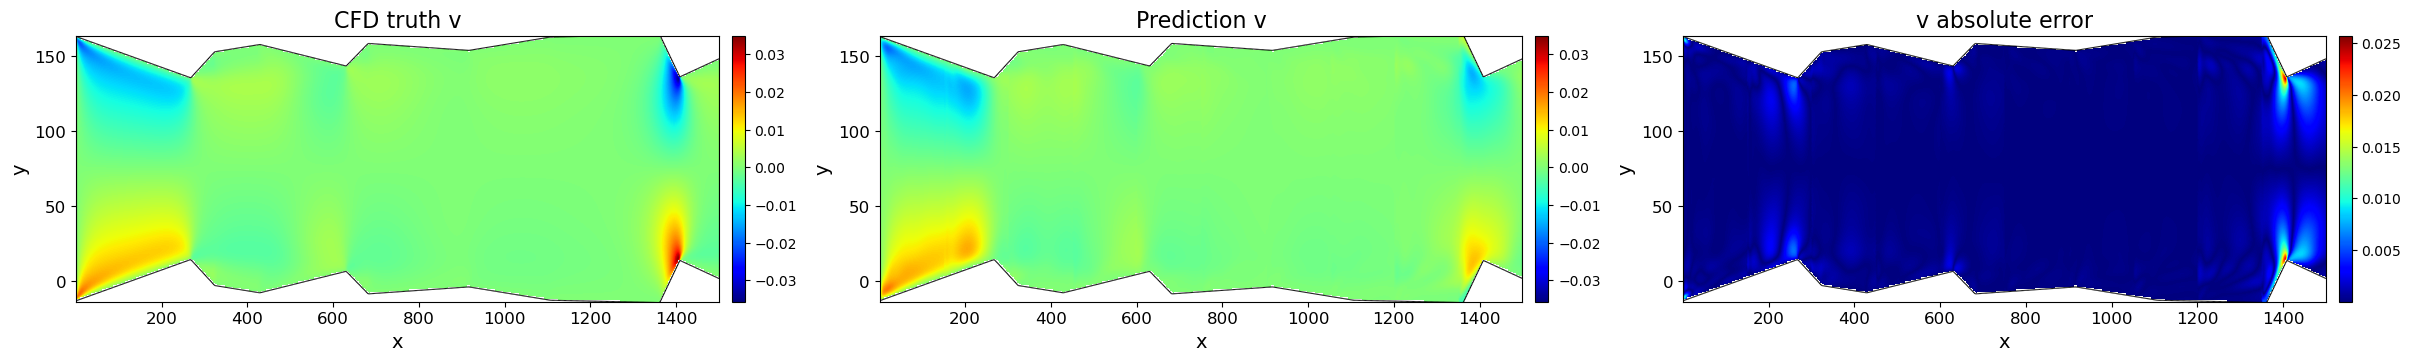

In [25]:
for c in TEST_CASES:
    sample_test_ids = sorted(
        (i for i, mm in enumerate(test_data["metadata"]) if int(mm["case_id"]) == int(c)),
        key=lambda i: int(test_data["metadata"][i]["subdomain_id"]),
    )
    metadata = test_data["metadata"][sample_test_ids[0]]
    

    plot_data = collect_predictions_for_data(
        model=model,
        data=test_data,
        device=DEVICE,
        y_normalizer=y_normalizer,
        local_aspect_mean=local_aspect_mean,
        local_aspect_std=local_aspect_std,
        sample_indices=sample_test_ids,
    )

    print("Total plotted points:", plot_data["x"].shape[0])
    print("x range:", plot_data["x"].min(), plot_data["x"].max())
    print("y range:", plot_data["y"].min(), plot_data["y"].max())

    for field_name in output_channel_names:
        field_idx = output_channel_names.index(field_name)

        plot_prediction_imshow_from_points(
            x=plot_data["x"],
            y=plot_data["y"],
            pred=plot_data["pred"],
            truth=plot_data["truth"],
            field_name=field_name,
            field_idx=field_idx,
            n_y_plot=200,
            output_dir=output_dir / "predictions" / "test",
            filename_prefix=f"test_case{c:02d}",
            mesh_h5=case_files[test_data["metadata"][sample_test_ids[0]]["case_id"]]["mesh"],
        )